# Stack Overflow Survey Compensation Model

This notebook takes the cleaned respondent baseline built from `src/comp_clean.py`, sets modeling year windows, and fits the potential compensation models with the goal of estimating which factors are most associated with respondents' total compensation.

## Modeling Plan

1. Load `clean_core` from a parquet built from the cleaning notebook
2. Run a stricter country QA on the compensation sample
3. Inflation-adjust annual compensation to 2025 dollars using CPI-U annual averages
4. Compare the candidate modeling windows from the cleaning notebook
5. Fit a year-region median benchmark, then Ridge, ElasticNet, and ExtraTrees on the main window
6. Run later-year side models for the tech-rich and AI-era windows
7. Use permutation importance on the selected core model to see which feature families matter most
8. Test a two-stage geography backbone plus residual model to separate country effects from within-country signal


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Ignore noisy packages
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Set display parameters to view more and keep easy to view style
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42


# Robust method to make sure we have the correct file paths
def find_root():
    here = Path.cwd()
    for path in [here, *here.parents]:
        if (path / 'data').exists():
            return path
    raise FileNotFoundError("Could not find project root")

ROOT = find_root()
DATA_DIR = ROOT / 'data'
DERIVED_DIR = DATA_DIR / 'derived'
print(ROOT)

c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis


## Load Finalized Clean Core

Double checks to make sure the `clean_core.parquet` file exists and that the columns are formatted as expected for the models.

In [2]:
CLEAN_PATH = DERIVED_DIR / 'clean_core.parquet'

if not CLEAN_PATH.exists():
    raise FileNotFoundError("Run `python src/comp_clean.py` first to build data/derived/clean_core.parquet")

clean_core = pd.read_parquet(CLEAN_PATH)
string_cols = clean_core.select_dtypes(include='string').columns
clean_core[string_cols] = clean_core[string_cols].astype(object)
clean_core[string_cols] = clean_core[string_cols].where(pd.notna(clean_core[string_cols]), np.nan)
clean_core['survey_year_str'] = clean_core['survey_year'].astype(str)
role_cols = sorted(col for col in clean_core.columns if col.startswith('role_'))

print(CLEAN_PATH)
print(clean_core.shape)
display(clean_core[['survey_year', 'country_clean', 'region', 'comp_real_2025'] + role_cols[:4]].sample(5, random_state=RANDOM_STATE))

c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis\data\derived\clean_core.parquet
(746226, 84)


,survey_year,country_clean,region,comp_real_2025,role_back_end,role_data_ml,role_desktop_enterprise,role_devops_cloud
660422,2024,Thailand,Asia,NaN,0,0,0,0
115194,2017,New Zealand,Oceania,NaN,0,0,0,0
462718,2021,Denmark,Europe,140320.906639,1,0,1,0
683102,2024,United States,Americas,NaN,1,0,0,0
116754,2017,United States,Americas,NaN,0,0,0,0


## Loaded Data QA

Checks the number of country responses with unmapped cleaned country values and regions per year, displays the unmapped values, and shows salary trend before and after inflation adjustment.

,window,rows,missing_country_clean,missing_region
0,2019+ core,240651,125,125
1,2021+ tech,160783,59,59
2,2023+ AI,84833,28,28


Remaining raw countries with missing country_clean inside the compensation sample


country
Other Country (Not Listed Above)    86
Nomadic                             71
Other (please specify)              13
I prefer not to say                  6
Name: count, dtype: int64

,survey_year,comp_usd_clean,comp_real_2025
0,2019,56376.0,70993.00
1,2020,54000.0,67172.27
2,2021,55224.0,65612.36
3,2022,66540.0,73199.12
4,2023,75397.0,79663.20
5,2024,67666.0,69446.47
6,2025,80050.0,80050.00


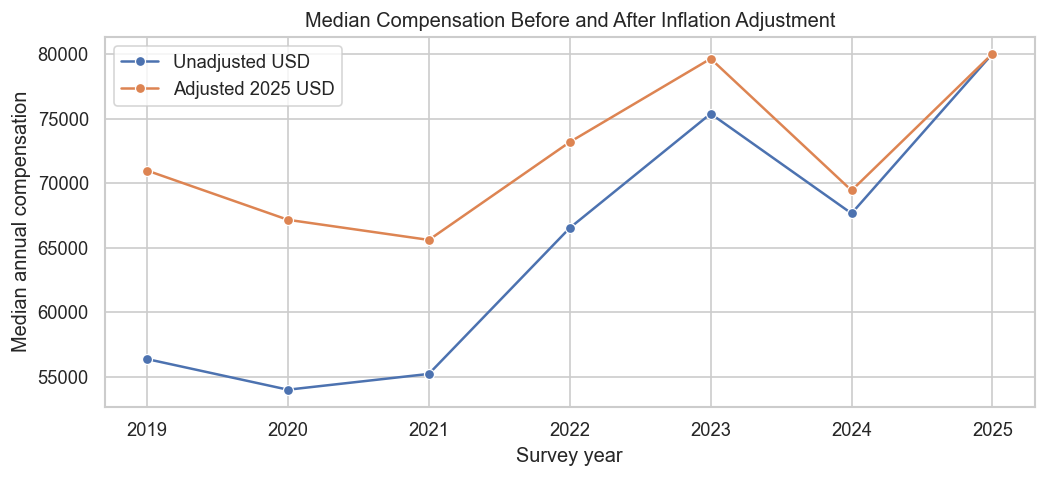

In [3]:
# Builds DataFrame defining windows we intend to use and the missing countries and regions in each
country_qa = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': int(clean_core['is_comp_model_core'].sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_core'], 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_core'], 'region'].isna().sum())
    },
    {
        'window': '2021+ tech',
        'rows': int(clean_core['is_comp_model_tech_rich'].sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_tech_rich'], 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_tech_rich'], 'region'].isna().sum())
    },
    {
        'window': '2023+ AI',
        'rows': int(clean_core['is_comp_model_ai_era'].sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_ai_era'], 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_ai_era'], 'region'].isna().sum())
    }
])
display(country_qa)

print("Remaining raw countries with missing country_clean inside the compensation sample")
display(clean_core.loc[clean_core['is_comp_analysis_sample'] & clean_core['country_clean'].isna(), 'country'].value_counts().head(15))

# Median compensation per year, before and after inflation adjustment
median_comp = clean_core.loc[clean_core['is_comp_model_core']].groupby('survey_year')[['comp_usd_clean', 'comp_real_2025']].median().reset_index()
display(median_comp.round(2))

# Trendlines for compensation
plt.figure(figsize=(10, 4))
sns.lineplot(data=median_comp, x='survey_year', y='comp_usd_clean', marker='o', label='Unadjusted USD')
sns.lineplot(data=median_comp, x='survey_year', y='comp_real_2025', marker='o', label='Adjusted 2025 USD')
plt.title("Median Compensation Before and After Inflation Adjustment")
plt.xlabel("Survey year")
plt.ylabel("Median annual compensation")
plt.legend()
plt.show()

## Final Window Choice

The main model should use the window that covers the most years and has reasonable feature coverage this will be 2019+. The later windows can still be used as side models to look at changes from including learning channels, remote work, and AI fields. Since this is temporal data, we'll need to do data splits on time. 2025 will always be the test set, 2024 will be the validation set, and the rest will be the training set. We can't do a more granular split since the responses are just recorded by year, there's no other time separation.

In [4]:
# Define DataFrames for each of the windows we intend to look at (only including rows with region data)
core_df = clean_core[clean_core['is_comp_model_core'] & clean_core['country_clean'].notna()].copy()
tech_df = clean_core[clean_core['is_comp_model_tech_rich'] & clean_core['country_clean'].notna()].copy()
ai_df = clean_core[clean_core['is_comp_model_ai_era'] & clean_core['country_clean'].notna()].copy()

# Show how many rows we have per window as well as the coverage of major features
window_summary = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': len(core_df),
        'train_years': '2019-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(core_df['age_mid'].notna().mean(), 3),
        'experience_share': round(core_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(core_df['country_clean'].notna().mean(), 3),
        'remote_share': round(core_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(core_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2021+ tech',
        'rows': len(tech_df),
        'train_years': '2021-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(tech_df['age_mid'].notna().mean(), 3),
        'experience_share': round(tech_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(tech_df['country_clean'].notna().mean(), 3),
        'remote_share': round(tech_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(tech_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2023+ AI',
        'rows': len(ai_df),
        'train_years': '2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(ai_df['age_mid'].notna().mean(), 3),
        'experience_share': round(ai_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(ai_df['country_clean'].notna().mean(), 3),
        'remote_share': round(ai_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(ai_df['ai_sent'].notna().mean(), 3)
    }
])
display(window_summary)

print("Main compensation window: 2019+ core")
print("Side windows: 2021+ tech and 2023+ AI")

,window,rows,train_years,valid_year,test_year,age_share,experience_share,country_share,remote_share,ai_sent_share
0,2019+ core,240526,2019-2023,2024,2025,0.976,0.991,1.0,0.680,0.273
1,2021+ tech,160724,2021-2023,2024,2025,0.998,0.992,1.0,0.726,0.408
2,2023+ AI,84805,2023,2024,2025,0.999,0.994,1.0,0.977,0.773


Main compensation window: 2019+ core
Side windows: 2021+ tech and 2023+ AI


## Feature Sets And Helpers

The core model uses geography, employment, education, organization size, experience, role family, and tech knowledge counts. The side models add fields that only surface in later survey years.


In [ ]:
# Categorical and numeric fields for the core model
CORE_CAT = ['survey_year_str', 'region', 'country_clean', 'employment_group', 'education_clean', 'org_size_clean']
CORE_NUM = ['age_mid', 'professional_experience_years', 'language_count', 'database_count', 'platform_count'] + role_cols

# Categorical and numeric fields for the core model
TECH_CAT = CORE_CAT.copy()
TECH_NUM = CORE_NUM + ['learn_code_count', 'webframe_count', 'misc_tech_count']

# Categorical and numeric fields for the core model
AI_CAT = CORE_CAT + ['remote_group', 'ai_use', 'ai_sent']
AI_NUM = TECH_NUM + ['learn_code_online_count', 'coding_activities_count', 'op_sys_prof_count']

TARGET_COL = 'log_comp_real_2025'



# Split data into train, validation, and test sets based on ranges we defined earlier
def split_years(frame, train_years, valid_year, test_year):
    train = frame[frame['survey_year'].isin(train_years)].copy()
    valid = frame[frame['survey_year'] == valid_year].copy()
    test = frame[frame['survey_year'] == test_year].copy()
    return train, valid, test


# Performs full round of evaluation metrics on given model outputs
def score_predictions(y_true_log, pred_log):
    y_true_real = np.exp(y_true_log)
    pred_real = np.exp(pred_log)
    return {
        'medae_real': median_absolute_error(y_true_real, pred_real),
        'mae_real': mean_absolute_error(y_true_real, pred_real),
        'rmse_real': np.sqrt(mean_squared_error(y_true_real, pred_real)),
        'rmse_log': np.sqrt(mean_squared_error(y_true_log, pred_log)),
        'r2_log': r2_score(y_true_log, pred_log)
    }


# Pipeline for linear model. Fits prep imputation, encoding, and scaling to training data and applies it to val/test data
def build_linear_pipe(cat_cols, num_cols):
    prep = ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('encode', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=500))
        ]), cat_cols),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_cols)
    ])
    return Pipeline([
        ('prep', prep),
        ('model', Ridge())
    ])


# Pipeline for tree model. Fits prep imputation, encoding, and scaling to training data and applies it to val/test data
def build_tree_pipe(cat_cols, num_cols):
    prep = ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1))
        ]), cat_cols),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median'))
        ]), num_cols)
    ])
    return Pipeline([
        ('prep', prep),
        ('model', ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])


# Takes all passed values needed to create, fit, and evaluate each model
def search_and_test(name, pipe, param_grid, train_df, valid_df, test_df, feature_cols):
    X_train = train_df[feature_cols]
    y_train = train_df[TARGET_COL]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[TARGET_COL]
    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COL]

    trials = []
    best_params = None
    best_valid = None

    for params in param_grid:
        est = clone(pipe)
        est.set_params(**params)
        est.fit(X_train, y_train)
        valid_metrics = score_predictions(y_valid, est.predict(X_valid))

        row = {'model': name, **params, **{f'valid_{k}': v for k, v in valid_metrics.items()}}
        trials.append(row)

        if best_valid is None or valid_metrics['medae_real'] < best_valid['medae_real']:
            best_valid = valid_metrics
            best_params = params

    final_est = clone(pipe)
    final_est.set_params(**best_params)
    X_train_valid = pd.concat([X_train, X_valid], axis=0)
    y_train_valid = pd.concat([y_train, y_valid], axis=0)
    final_est.fit(X_train_valid, y_train_valid)
    test_metrics = score_predictions(y_test, final_est.predict(X_test))

    return pd.DataFrame(trials), final_est, best_params, best_valid, test_metrics


# Method to score the baseline model that our built models will be compared to
def score_year_region_benchmark(train_df, valid_df, test_df):
    year_region = train_df.groupby(['survey_year', 'region'])['comp_real_2025'].median().rename('pred').reset_index()
    year_only = train_df.groupby('survey_year')['comp_real_2025'].median().rename('pred_year').reset_index()
    overall = train_df['comp_real_2025'].median()

    def predict(frame):
        out = frame[['survey_year', 'region']].merge(year_region, on=['survey_year', 'region'], how='left')
        out = out.merge(year_only, on='survey_year', how='left')
        pred_real = out['pred'].fillna(out['pred_year']).fillna(overall)
        return np.log(pred_real)

    valid_metrics = score_predictions(valid_df[TARGET_COL], predict(valid_df))
    test_metrics = score_predictions(test_df[TARGET_COL], predict(test_df))
    return valid_metrics, test_metrics


# Loss function that will be used to score permutation importance, median since financial data is always skewed
def medae_real_loss(estimator, X, y_log):
    pred_log = estimator.predict(X)
    return -median_absolute_error(np.exp(y_log), np.exp(pred_log))

## Benchmark

This is an intentionally simple baseline model that predicts the training set median real compensation for each survey year and region. If a year-region pair is missing, it falls back to the year median and then the overall median.


In [6]:
core_train, core_valid, core_test = split_years(core_df, [2019, 2020, 2021, 2022, 2023], 2024, 2025)

benchmark_valid, benchmark_test = score_year_region_benchmark(core_train, core_valid, core_test)
benchmark_results = pd.DataFrame([{
    'model': 'Year-region median benchmark',
    'valid_medae_real': benchmark_valid['medae_real'],
    'valid_rmse_real': benchmark_valid['rmse_real'],
    'valid_rmse_log': benchmark_valid['rmse_log'],
    'test_medae_real': benchmark_test['medae_real'],
    'test_rmse_real': benchmark_test['rmse_real'],
    'test_rmse_log': benchmark_test['rmse_log']
}])
display(benchmark_results.round(2))

,model,valid_medae_real,valid_rmse_real,valid_rmse_log,test_medae_real,test_rmse_real,test_rmse_log
0,Year-region median benchmark,37817.82,80254.4,1.09,38074.73,88700.37,1.05


## Core Models

These are the first real models on the final main window. The benchmark sets the baseline capability and the linear models check how much the additional fields and model setup improve predictions. ExtraTrees gives a nonlinear comparison without requiring us to pull in new dependencies. I chose ExtraTrees over RandomForest because it adds an additional layer of randomization by choose a random threshold for node split values which makes it computationally faster and works better for how noisy our data is, won't get stuck searching for an optimal value.

**This can take several minutes to run, it does multiple trials of multiple models.**


In [7]:
core_features = CORE_CAT + CORE_NUM

# Linear model using Ridge Regression
ridge_pipe = build_linear_pipe(CORE_CAT, CORE_NUM)
ridge_trials, ridge_model, ridge_params, ridge_valid, ridge_test = search_and_test(
    'Ridge',
    ridge_pipe,
    [
        {'model': Ridge(alpha=1.0)},
        {'model': Ridge(alpha=5.0)},
        {'model': Ridge(alpha=10.0)},
        {'model': Ridge(alpha=25.0)}
    ],
    core_train,
    core_valid,
    core_test,
    core_features
)

# Linear model using Elastic Net regularization
elastic_pipe = build_linear_pipe(CORE_CAT, CORE_NUM)
elastic_trials, elastic_model, elastic_params, elastic_valid, elastic_test = search_and_test(
    'ElasticNet',
    elastic_pipe,
    [
        {'model': ElasticNet(alpha=0.001, l1_ratio=0.1, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.005, l1_ratio=0.2, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=5000, random_state=RANDOM_STATE)}
    ],
    core_train,
    core_valid,
    core_test,
    core_features
)

# Nonlinear model using the ExtraTreesRegressor
extra_pipe = build_tree_pipe(CORE_CAT, CORE_NUM)
extra_trials, extra_model, extra_params, extra_valid, extra_test = search_and_test(
    'ExtraTrees',
    extra_pipe,
    [
        {'model__n_estimators': 80, 'model__max_depth': None, 'model__min_samples_leaf': 1},
        {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5}
    ],
    core_train,
    core_valid,
    core_test,
    core_features
)

# Show the results for each parameter set of each model
print("Linear Ridge model trials:")
display(ridge_trials.round(2))
print("\nLinear Elastic Net model trials:")
display(elastic_trials.round(2))
print("\nNonlinear ExtraTrees model trials:")
display(extra_trials.round(2))


# All four model's results, sorted by lowest validation median absolute error
core_results = pd.DataFrame(
    [
        {
            'model': 'Year-region median benchmark',
            'valid_medae_real': benchmark_valid['medae_real'],
            'valid_rmse_real': benchmark_valid['rmse_real'],
            'test_medae_real': benchmark_test['medae_real'],
            'test_rmse_real': benchmark_test['rmse_real'],
            'test_r2_log': benchmark_test['r2_log']
        },
        {
            'model': 'Ridge',
            'valid_medae_real': ridge_valid['medae_real'],
            'valid_rmse_real': ridge_valid['rmse_real'],
            'test_medae_real': ridge_test['medae_real'],
            'test_rmse_real': ridge_test['rmse_real'],
            'test_r2_log': ridge_test['r2_log']
        },
        {
            'model': 'ElasticNet',
            'valid_medae_real': elastic_valid['medae_real'],
            'valid_rmse_real': elastic_valid['rmse_real'],
            'test_medae_real': elastic_test['medae_real'],
            'test_rmse_real': elastic_test['rmse_real'],
            'test_r2_log': elastic_test['r2_log']
        },
        {
            'model': 'ExtraTrees',
            'valid_medae_real': extra_valid['medae_real'],
            'valid_rmse_real': extra_valid['rmse_real'],
            'test_medae_real': extra_test['medae_real'],
            'test_rmse_real': extra_test['rmse_real'],
            'test_r2_log': extra_test['r2_log']
        }
    ]
).sort_values('valid_medae_real')

print("\nEvaluation metrics for top performing trial of each model:")
display(core_results.round(2))

# Get the best performing model based on our evaluation metrics
best_core_model = extra_model if core_results.iloc[0]['model'] == 'ExtraTrees' else ridge_model if core_results.iloc[0]['model'] == 'Ridge' else elastic_model
best_core_name = core_results.iloc[0]['model']
print(f"\nBest performing trial based on median absolute error: {best_core_name}")


Linear Ridge model trials:


,model,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,Ridge(),19864.06,34245.48,61911.50,0.74,0.53
1,Ridge(alpha=5.0),19854.37,34239.68,61909.03,0.74,0.53
2,Ridge(alpha=10.0),19845.54,34233.01,61906.41,0.74,0.53
3,Ridge(alpha=25.0),19803.63,34213.83,61899.06,0.74,0.53



Linear Elastic Net model trials:


,model,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,"ElasticNet(alpha=0.001, l1_ratio=0.1, max_iter...",19966.20,34485.35,62058.83,0.74,0.52
1,"ElasticNet(alpha=0.001, max_iter=5000, random_...",19911.33,34405.44,62032.94,0.74,0.52
2,"ElasticNet(alpha=0.005, l1_ratio=0.2, max_iter...",19997.88,34570.71,62429.70,0.76,0.49
3,"ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=...",20479.78,35156.28,63154.49,0.78,0.46



Nonlinear ExtraTrees model trials:


,model,model__n_estimators,model__max_depth,model__min_samples_leaf,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,ExtraTrees,80,NaN,1,22104.28,37031.96,64745.71,0.75,0.51
1,ExtraTrees,80,24.0,5,20619.09,33074.72,58963.38,0.72,0.54



Evaluation metrics for top performing trial of each model:


,model,valid_medae_real,valid_rmse_real,test_medae_real,test_rmse_real,test_r2_log
1,Ridge,19803.63,61899.06,22294.30,72711.22,0.49
2,ElasticNet,19911.33,62032.94,22225.62,70873.40,0.49
3,ExtraTrees,20619.09,58963.38,25276.58,68537.11,0.48
0,Year-region median benchmark,37817.82,80254.40,38074.73,88700.37,-0.01



Best performing trial based on median absolute error: Ridge


## Later Year Side Models

These are not replacements for the main model. They are to check whether newer fields improve prediction once the survey begins to include them more consistently.


In [8]:
# Split tech and AI windows on years the contain them
tech_train, tech_valid, tech_test = split_years(tech_df, [2021, 2022, 2023], 2024, 2025)
ai_train, ai_valid, ai_test = split_years(ai_df, [2023], 2024, 2025)

tech_features = TECH_CAT + TECH_NUM
ai_features = AI_CAT + AI_NUM

# Nonlinear ExtraTrees model of the increased tech tracking window (2021+)
tech_pipe = build_tree_pipe(TECH_CAT, TECH_NUM)
tech_trials, tech_model, tech_params, tech_valid_metrics, tech_test_metrics = search_and_test(
    'Tech-rich ExtraTrees',
    tech_pipe,
    [
        {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5},
        {'model__n_estimators': 80, 'model__max_depth': None, 'model__min_samples_leaf': 5}
    ],
    tech_train,
    tech_valid,
    tech_test,
    tech_features
)

# Nonlinear ExtraTrees model of the increased ai tracking window (2023+)
ai_pipe = build_tree_pipe(AI_CAT, AI_NUM)
ai_trials, ai_model, ai_params, ai_valid_metrics, ai_test_metrics = search_and_test(
    'AI-era ExtraTrees',
    ai_pipe,
    [
        {'model__n_estimators': 80, 'model__max_depth': 18, 'model__min_samples_leaf': 5},
        {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5}
    ],
    ai_train,
    ai_valid,
    ai_test,
    ai_features
)

print("Tech window (2021+) side model trials:")
display(tech_trials.round(2))
print("\nAi window (2023+) side model trials:")
display(ai_trials.round(2))

# Comparison of all evaluation metrics for the two side models
side_results = pd.DataFrame(
    [
        {
            'model': 'Tech-rich ExtraTrees',
            'valid_medae_real': tech_valid_metrics['medae_real'],
            'test_medae_real': tech_test_metrics['medae_real'],
            'test_rmse_real': tech_test_metrics['rmse_real'],
            'test_r2_log': tech_test_metrics['r2_log']
        },
        {
            'model': 'AI-era ExtraTrees',
            'valid_medae_real': ai_valid_metrics['medae_real'],
            'test_medae_real': ai_test_metrics['medae_real'],
            'test_rmse_real': ai_test_metrics['rmse_real'],
            'test_r2_log': ai_test_metrics['r2_log']
        }
    ]
)

print("\nEvaluation metrics for best performing of both side model trials:")
display(side_results.round(2))

Tech window (2021+) side model trials:


,model,model__n_estimators,model__max_depth,model__min_samples_leaf,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,Tech-rich ExtraTrees,80,24.0,5,17991.74,30495.38,56994.43,0.72,0.55
1,Tech-rich ExtraTrees,80,NaN,5,18098.03,30672.28,57109.05,0.72,0.55



Ai window (2023+) side model trials:


,model,model__n_estimators,model__max_depth,model__min_samples_leaf,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,AI-era ExtraTrees,80,18,5,17745.50,30336.47,57532.39,0.71,0.56
1,AI-era ExtraTrees,80,24,5,17546.65,30180.21,57250.78,0.70,0.56



Evaluation metrics for best performing of both side model trials:


,model,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
0,Tech-rich ExtraTrees,17991.74,23333.85,66304.41,0.48
1,AI-era ExtraTrees,17546.65,21387.45,66941.63,0.50


## Full Model Feature Importance

Uses permutation importance on the core model and validation set to summarize which features are influencing compensation the most on  a feature-family level.


Top 15 features by permutation importance:


,feature,importance,family
2,country_clean,25620.56,Geography
1,region,4371.66,Geography
7,professional_experience_years,3529.46,Experience and age
5,org_size_clean,1473.18,Organization size
3,employment_group,1437.17,Employment
4,education_clean,834.84,Education
8,language_count,180.11,Tech breadth
18,role_management,178.82,Role family
22,role_student_academic,115.63,Role family
11,role_back_end,81.31,Role family



Top families by permutation importance:


,family,importance
3,Geography,29992.22
2,Experience and age,3517.46
4,Organization size,1473.18
1,Employment,1437.17
0,Education,834.84
5,Role family,466.97
6,Tech breadth,136.53
7,Time,0.00


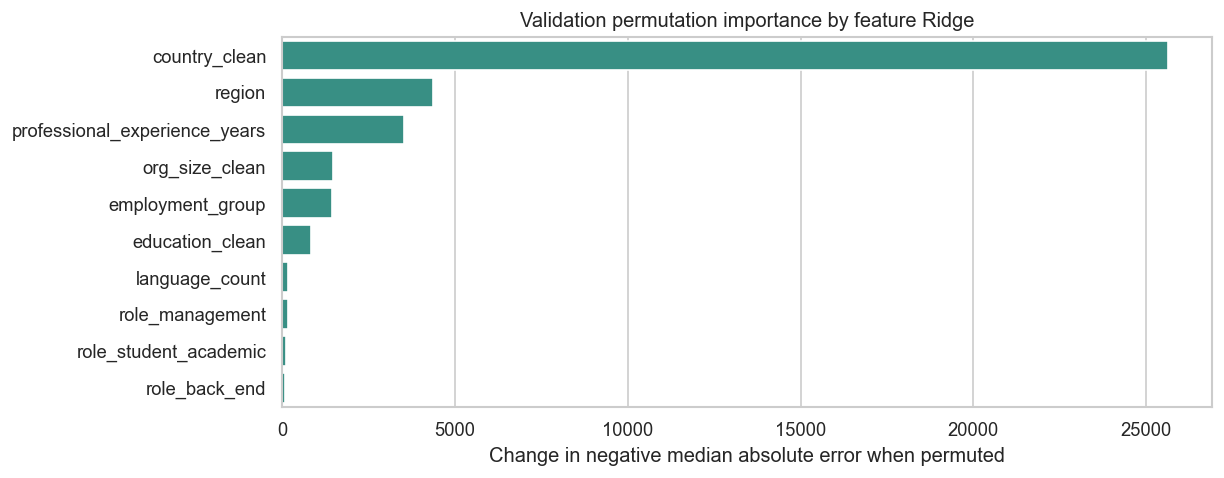

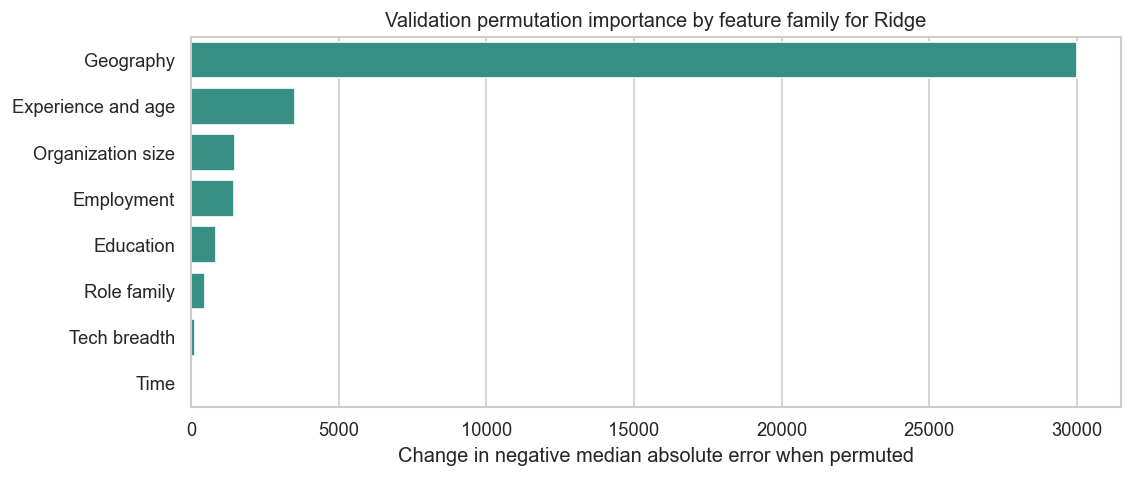

In [ ]:
# Groups the features into families of related concepts
family_map = {
    'survey_year_str': 'Time',
    'region': 'Geography',
    'country_clean': 'Geography',
    'employment_group': 'Employment',
    'education_clean': 'Education',
    'org_size_clean': 'Organization size',
    'age_mid': 'Experience and age',
    'professional_experience_years': 'Experience and age',
    'language_count': 'Tech breadth',
    'database_count': 'Tech breadth',
    'platform_count': 'Tech breadth'
}
for col in role_cols:
    family_map[col] = 'Role family'

# Runs permutation importance with validation set using the defined median absolute error loss function
valid_perm = permutation_importance(
    best_core_model,
    core_valid[core_features],
    core_valid[TARGET_COL],
    scoring=medae_real_loss,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': core_features,
    'importance': valid_perm.importances_mean,
    'family': [family_map.get(col, 'Other') for col in core_features]
}).sort_values('importance', ascending=False)

print("Top 15 features by permutation importance:")
display(perm_df.head(15).round(2))

# Group the features into the respective family and sum their importance values
family_imp = perm_df.groupby('family', as_index=False)['importance'].sum().sort_values('importance', ascending=False)

print("\nTop families by permutation importance:")
display(family_imp.round(2))

# Visualization of the family-level permutation importance
plt.figure(figsize=(10, 4))
sns.barplot(data=perm_df.head(10), x='importance', y='feature', color='#2A9D8F')
plt.title(f"Validation permutation importance by feature {best_core_name}")
plt.xlabel("Change in negative median absolute error when permuted")
plt.ylabel("")
plt.show()

# Visualization of the family-level permutation importance
plt.figure(figsize=(10, 4))
sns.barplot(data=family_imp, x='importance', y='family', color='#2A9D8F')
plt.title(f"Validation permutation importance by feature family for {best_core_name}")
plt.xlabel("Change in negative median absolute error when permuted")
plt.ylabel("")
plt.show()

## Country-Fixed Subgroup Models

To control for geography dominating feature importance, fit separate 2019+ core models for `United States`, `Germany`, and `India`. Each subgroup keeps the same year-aware split as the full model and explicitly removes `region` and `country_clean` so the model has to learn from within-country variation instead.

In [9]:
COUNTRY_FOCUS = ['United States', 'Germany', 'India']
COUNTRY_CAT = [col for col in CORE_CAT if col not in ['region', 'country_clean']]
COUNTRY_NUM = CORE_NUM.copy()
COUNTRY_FEATURES = COUNTRY_CAT + COUNTRY_NUM

# Lower the infrequent threshold a bit since these are smaller country-specific slices
def build_country_linear_pipe(cat_cols, num_cols):
    prep = ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('encode', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100))
        ]), cat_cols),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_cols)
    ])
    return Pipeline([
        ('prep', prep),
        ('model', Ridge())
    ])


# Country is fixed here, so the naive benchmark only gets year-level medians
def score_year_only_benchmark(train_df, valid_df, test_df):
    year_only = train_df.groupby('survey_year')['comp_real_2025'].median().rename('pred_year').reset_index()
    overall = train_df['comp_real_2025'].median()

    def predict(frame):
        out = frame[['survey_year']].merge(year_only, on='survey_year', how='left')
        pred_real = out['pred_year'].fillna(overall)
        return np.log(pred_real)

    valid_metrics = score_predictions(valid_df[TARGET_COL], predict(valid_df))
    test_metrics = score_predictions(test_df[TARGET_COL], predict(test_df))
    return valid_metrics, test_metrics


country_year_counts = (
    core_df.loc[core_df['country_clean'].isin(COUNTRY_FOCUS)]
    .groupby(['country_clean', 'survey_year'])
    .size()
    .unstack(fill_value=0)
    .reindex(COUNTRY_FOCUS)
)

print("Compensation-model sample counts by country and year:")
display(country_year_counts)

country_family_map = {
    'survey_year_str': 'Time',
    'employment_group': 'Employment',
    'education_clean': 'Education',
    'org_size_clean': 'Organization size',
    'age_mid': 'Experience and age',
    'professional_experience_years': 'Experience and age',
    'language_count': 'Tech breadth',
    'database_count': 'Tech breadth',
    'platform_count': 'Tech breadth'
}
for col in role_cols:
    country_family_map[col] = 'Role family'

country_results = []
country_perm = []

for country in COUNTRY_FOCUS:
    country_df = core_df[core_df['country_clean'] == country].copy()
    country_train, country_valid, country_test = split_years(country_df, [2019, 2020, 2021, 2022, 2023], 2024, 2025)

    if min(len(country_train), len(country_valid), len(country_test)) == 0:
        raise ValueError(f"{country} is missing one of the required time splits")

    bench_valid, bench_test = score_year_only_benchmark(country_train, country_valid, country_test)

    ridge_trials_country, ridge_model_country, ridge_params_country, ridge_valid_country, ridge_test_country = search_and_test(
        f'{country} Ridge',
        build_country_linear_pipe(COUNTRY_CAT, COUNTRY_NUM),
        [
            {'model': Ridge(alpha=1.0)},
            {'model': Ridge(alpha=5.0)},
            {'model': Ridge(alpha=10.0)},
            {'model': Ridge(alpha=25.0)}
        ],
        country_train,
        country_valid,
        country_test,
        COUNTRY_FEATURES
    )

    extra_trials_country, extra_model_country, extra_params_country, extra_valid_country, extra_test_country = search_and_test(
        f'{country} ExtraTrees',
        build_tree_pipe(COUNTRY_CAT, COUNTRY_NUM),
        [
            {'model__n_estimators': 80, 'model__max_depth': None, 'model__min_samples_leaf': 1},
            {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5}
        ],
        country_train,
        country_valid,
        country_test,
        COUNTRY_FEATURES
    )

    country_model_results = pd.DataFrame([
        {
            'country_clean': country,
            'model': 'Year-only median benchmark',
            'valid_medae_real': bench_valid['medae_real'],
            'test_medae_real': bench_test['medae_real'],
            'test_rmse_real': bench_test['rmse_real'],
            'test_r2_log': bench_test['r2_log']
        },
        {
            'country_clean': country,
            'model': 'Ridge',
            'valid_medae_real': ridge_valid_country['medae_real'],
            'test_medae_real': ridge_test_country['medae_real'],
            'test_rmse_real': ridge_test_country['rmse_real'],
            'test_r2_log': ridge_test_country['r2_log']
        },
        {
            'country_clean': country,
            'model': 'ExtraTrees',
            'valid_medae_real': extra_valid_country['medae_real'],
            'test_medae_real': extra_test_country['medae_real'],
            'test_rmse_real': extra_test_country['rmse_real'],
            'test_r2_log': extra_test_country['r2_log']
        }
    ]).sort_values('valid_medae_real')

    best_country_name = country_model_results.iloc[0]['model']
    best_country_model = extra_model_country if best_country_name == 'ExtraTrees' else ridge_model_country

    country_results.append({
        'country_clean': country,
        'train_rows': len(country_train),
        'valid_rows': len(country_valid),
        'test_rows': len(country_test),
        'benchmark_valid_medae_real': bench_valid['medae_real'],
        'benchmark_test_medae_real': bench_test['medae_real'],
        'best_model': best_country_name,
        'valid_medae_real': country_model_results.iloc[0]['valid_medae_real'],
        'test_medae_real': country_model_results.iloc[0]['test_medae_real'],
        'test_rmse_real': country_model_results.iloc[0]['test_rmse_real'],
        'test_r2_log': country_model_results.iloc[0]['test_r2_log']
    })

    country_perm_raw = permutation_importance(
        best_country_model,
        country_valid[COUNTRY_FEATURES],
        country_valid[TARGET_COL],
        scoring=medae_real_loss,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    country_perm_df = pd.DataFrame({
        'country_clean': country,
        'feature': COUNTRY_FEATURES,
        'importance': country_perm_raw.importances_mean,
        'family': [country_family_map.get(col, 'Other') for col in COUNTRY_FEATURES]
    }).sort_values('importance', ascending=False)
    country_perm_df['rank'] = np.arange(1, len(country_perm_df) + 1)
    country_perm.append(country_perm_df)

country_results = pd.DataFrame(country_results).sort_values('valid_medae_real')
country_perm = pd.concat(country_perm, ignore_index=True)

print("\nCountry-fixed model summary with geography removed from features:")
display(country_results.round(2))


Compensation-model sample counts by country and year:


survey_year,2019,2020,2021,2022,2023,2024,2025
country_clean,,,,,,,
United States,12369,6920,8576,7491,10821,4232,4403
Germany,3346,2085,2846,2571,3600,1811,1813
India,3649,2453,3611,2042,1751,966,929



Country-fixed model summary with geography removed from features:


,country_clean,train_rows,valid_rows,test_rows,benchmark_valid_medae_real,benchmark_test_medae_real,best_model,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
2,India,13506,966,929,10598.39,11461.47,Ridge,7661.76,8253.76,68838.93,0.23
1,Germany,14448,1811,1813,20201.32,20538.96,Ridge,16968.76,26434.21,50443.65,0.09
0,United States,46177,4232,4403,43998.83,45921.64,ExtraTrees,34903.16,38127.42,99368.78,0.24


Top 10 validation permutation importance features within each country:


,country_clean,rank,feature,family,importance
21,Germany,1,employment_group,Employment,2520.94
22,Germany,2,education_clean,Education,1887.83
23,Germany,3,professional_experience_years,Experience and age,1635.24
24,Germany,4,org_size_clean,Organization size,1059.93
25,Germany,5,role_student_academic,Role family,330.03
26,Germany,6,role_management,Role family,190.71
27,Germany,7,role_desktop_enterprise,Role family,102.27
28,Germany,8,role_other,Role family,56.41
29,Germany,9,role_mobile,Role family,42.68
30,Germany,10,language_count,Tech breadth,36.77


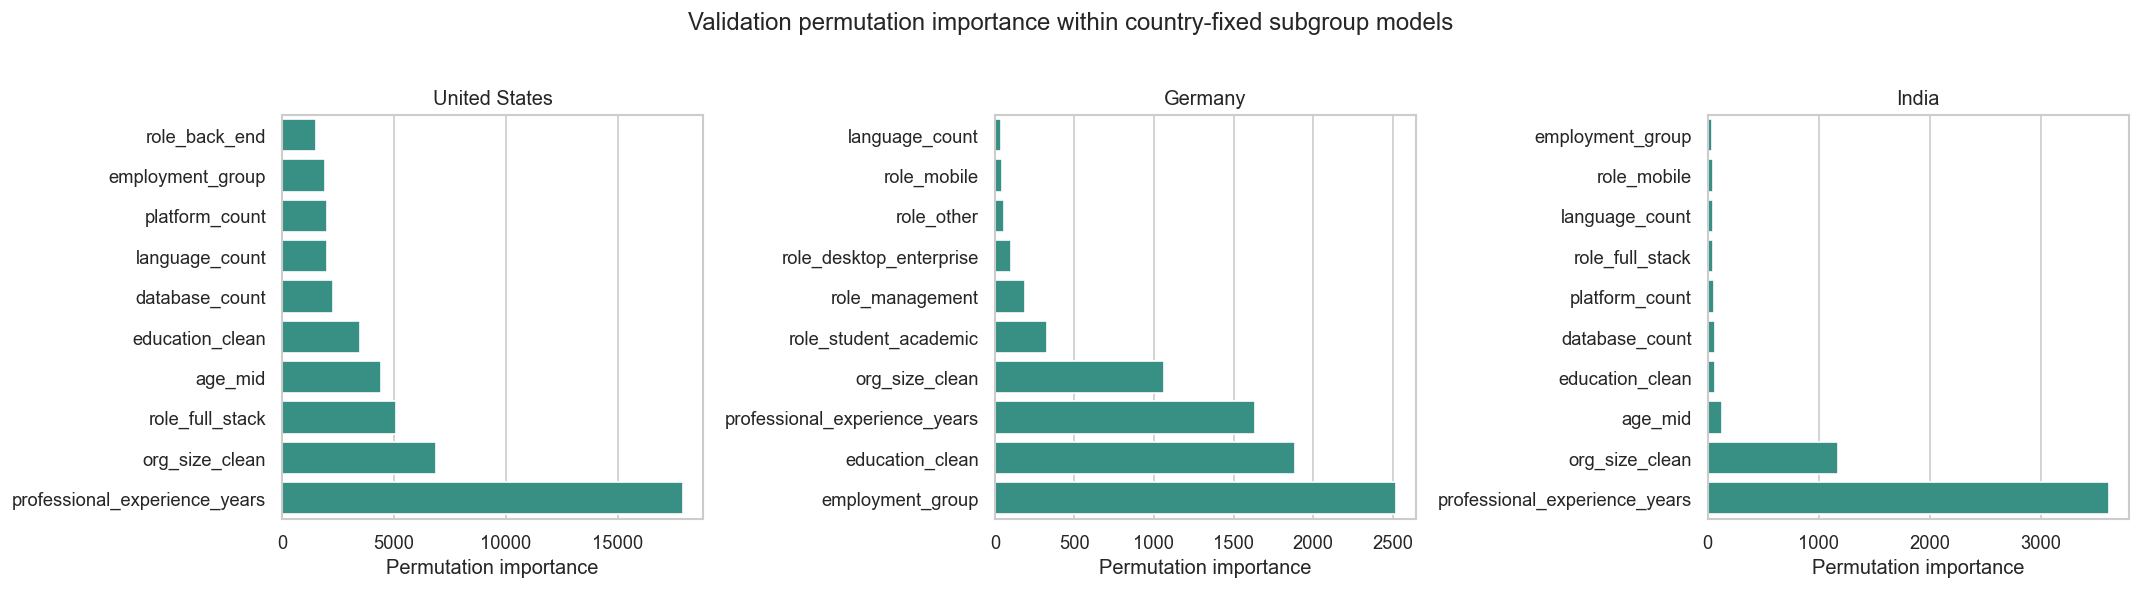


Summed feature-family importance within each country:


country_clean,Germany,India,United States
family,,,
Education,1887.83,69.99,3460.86
Employment,2520.94,37.32,1912.07
Experience and age,1655.33,3742.38,22335.70
Organization size,1059.93,1172.51,6870.67
Role family,774.04,23.62,11889.43
Tech breadth,32.79,173.95,6263.02
Time,0.00,0.00,0.00


In [10]:
country_top_perm = (
    country_perm
    .sort_values(['country_clean', 'importance'], ascending=[True, False])
    .groupby('country_clean')
    .head(10)
    .copy()
)

country_family_imp = (
    country_perm
    .groupby(['country_clean', 'family'], as_index=False)['importance']
    .sum()
)

print("Top 10 validation permutation importance features within each country:")
display(country_top_perm[['country_clean', 'rank', 'feature', 'family', 'importance']].round(2))

fig, axes = plt.subplots(1, len(COUNTRY_FOCUS), figsize=(18, 5))

for ax, country in zip(axes, COUNTRY_FOCUS):
    plot_df = country_top_perm[country_top_perm['country_clean'] == country].sort_values('importance', ascending=True)
    sns.barplot(data=plot_df, x='importance', y='feature', color='#2A9D8F', ax=ax)
    ax.set_title(country)
    ax.set_xlabel('Permutation importance')
    ax.set_ylabel('')

plt.suptitle('Validation permutation importance within country-fixed subgroup models')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nSummed feature-family importance within each country:")
display(
    country_family_imp
    .pivot(index='family', columns='country_clean', values='importance')
    .fillna(0)
    .round(2)
)


## Two-Stage Geography Backbone Plus Residual Model

A stronger predictive setup is to let geography handle the between-country level shifts, then use a second-stage model for the remaining within-country variation. Stage 1 predicts compensation from `survey_year x country_clean` medians with fallbacks to `survey_year x region`, `survey_year`, and then the overall median. Stage 2 predicts the remaining log compensation residual using only non-geographic respondent features.

In [11]:
# Stage 1 already owns year and geography, so stage 2 sticks to within-country respondent variation
RESIDUAL_CAT = ['employment_group', 'education_clean', 'org_size_clean']
RESIDUAL_NUM = CORE_NUM.copy()
RESIDUAL_FEATURES = RESIDUAL_CAT + RESIDUAL_NUM

def build_geo_backbone(train_df):
    country_year = train_df.groupby(['survey_year', 'country_clean'])['comp_real_2025'].median().rename('pred_country').reset_index()
    region_year = train_df.groupby(['survey_year', 'region'])['comp_real_2025'].median().rename('pred_region').reset_index()
    year_only = train_df.groupby('survey_year')['comp_real_2025'].median().rename('pred_year').reset_index()
    overall = train_df['comp_real_2025'].median()

    def predict(frame):
        out = frame[['survey_year', 'country_clean', 'region']].copy()
        out = out.merge(country_year, on=['survey_year', 'country_clean'], how='left')
        out = out.merge(region_year, on=['survey_year', 'region'], how='left')
        out = out.merge(year_only, on='survey_year', how='left')
        pred_real = out['pred_country'].fillna(out['pred_region']).fillna(out['pred_year']).fillna(overall)
        return pd.Series(np.log(pred_real.to_numpy()), index=frame.index)

    return predict


def score_geo_backbone(train_df, valid_df, test_df):
    valid_backbone = build_geo_backbone(train_df)
    valid_metrics = score_predictions(valid_df[TARGET_COL], valid_backbone(valid_df))

    train_valid = pd.concat([train_df, valid_df], axis=0)
    test_backbone = build_geo_backbone(train_valid)
    test_metrics = score_predictions(test_df[TARGET_COL], test_backbone(test_df))
    return valid_metrics, test_metrics


def search_two_stage(name, pipe, param_grid, train_df, valid_df, test_df, feature_cols):
    valid_backbone = build_geo_backbone(train_df)
    train_base_pred = valid_backbone(train_df)
    valid_base_pred = valid_backbone(valid_df)
    y_train_resid = train_df[TARGET_COL] - train_base_pred

    trials = []
    best_params = None
    best_valid = None
    best_valid_model = None

    for params in param_grid:
        est = clone(pipe)
        est.set_params(**params)
        est.fit(train_df[feature_cols], y_train_resid)
        valid_pred = valid_base_pred + est.predict(valid_df[feature_cols])
        valid_metrics = score_predictions(valid_df[TARGET_COL], valid_pred)

        row = {'model': name, **params, **{f'valid_{k}': v for k, v in valid_metrics.items()}}
        trials.append(row)

        if best_valid is None or valid_metrics['medae_real'] < best_valid['medae_real']:
            best_valid = valid_metrics
            best_params = params
            best_valid_model = est

    train_valid = pd.concat([train_df, valid_df], axis=0)
    test_backbone = build_geo_backbone(train_valid)
    train_valid_base_pred = test_backbone(train_valid)
    y_train_valid_resid = train_valid[TARGET_COL] - train_valid_base_pred

    final_est = clone(pipe)
    final_est.set_params(**best_params)
    final_est.fit(train_valid[feature_cols], y_train_valid_resid)

    test_pred = test_backbone(test_df) + final_est.predict(test_df[feature_cols])
    test_metrics = score_predictions(test_df[TARGET_COL], test_pred)

    return pd.DataFrame(trials), best_valid_model, valid_base_pred, final_est, best_params, best_valid, test_metrics


class ResidualStageWrapper:
    def __init__(self, base_pred, residual_model):
        self.base_pred = np.asarray(base_pred)
        self.residual_model = residual_model

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return self.base_pred + self.residual_model.predict(X)


geo_backbone_valid, geo_backbone_test = score_geo_backbone(core_train, core_valid, core_test)

resid_ridge_trials, resid_ridge_valid_model, resid_ridge_valid_base, resid_ridge_model, resid_ridge_params, resid_ridge_valid, resid_ridge_test = search_two_stage(
    'Two-stage Ridge residual',
    build_linear_pipe(RESIDUAL_CAT, RESIDUAL_NUM),
    [
        {'model': Ridge(alpha=1.0)},
        {'model': Ridge(alpha=5.0)},
        {'model': Ridge(alpha=10.0)},
        {'model': Ridge(alpha=25.0)}
    ],
    core_train,
    core_valid,
    core_test,
    RESIDUAL_FEATURES
)

resid_elastic_trials, resid_elastic_valid_model, resid_elastic_valid_base, resid_elastic_model, resid_elastic_params, resid_elastic_valid, resid_elastic_test = search_two_stage(
    'Two-stage ElasticNet residual',
    build_linear_pipe(RESIDUAL_CAT, RESIDUAL_NUM),
    [
        {'model': ElasticNet(alpha=0.001, l1_ratio=0.1, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.005, l1_ratio=0.2, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=5000, random_state=RANDOM_STATE)}
    ],
    core_train,
    core_valid,
    core_test,
    RESIDUAL_FEATURES
)

resid_extra_trials, resid_extra_valid_model, resid_extra_valid_base, resid_extra_model, resid_extra_params, resid_extra_valid, resid_extra_test = search_two_stage(
    'Two-stage ExtraTrees residual',
    build_tree_pipe(RESIDUAL_CAT, RESIDUAL_NUM),
    [
        {'model__n_estimators': 80, 'model__max_depth': None, 'model__min_samples_leaf': 1},
        {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5}
    ],
    core_train,
    core_valid,
    core_test,
    RESIDUAL_FEATURES
)

print("Geography backbone baseline metrics:")
display(pd.DataFrame([
    {
        'model': 'Country-region-year backbone',
        'valid_medae_real': geo_backbone_valid['medae_real'],
        'valid_rmse_real': geo_backbone_valid['rmse_real'],
        'test_medae_real': geo_backbone_test['medae_real'],
        'test_rmse_real': geo_backbone_test['rmse_real'],
        'test_r2_log': geo_backbone_test['r2_log']
    }
]).round(2))

print("\nTwo-stage Ridge residual model trials:")
display(resid_ridge_trials.round(2))
print("\nTwo-stage ElasticNet residual model trials:")
display(resid_elastic_trials.round(2))
print("\nTwo-stage ExtraTrees residual model trials:")
display(resid_extra_trials.round(2))

best_core_row = core_results.loc[core_results['model'] == best_core_name].iloc[0]

two_stage_results = pd.DataFrame([
    {
        'model': 'Year-region median benchmark',
        'valid_medae_real': benchmark_valid['medae_real'],
        'valid_rmse_real': benchmark_valid['rmse_real'],
        'test_medae_real': benchmark_test['medae_real'],
        'test_rmse_real': benchmark_test['rmse_real'],
        'test_r2_log': benchmark_test['r2_log']
    },
    {
        'model': 'Country-region-year backbone',
        'valid_medae_real': geo_backbone_valid['medae_real'],
        'valid_rmse_real': geo_backbone_valid['rmse_real'],
        'test_medae_real': geo_backbone_test['medae_real'],
        'test_rmse_real': geo_backbone_test['rmse_real'],
        'test_r2_log': geo_backbone_test['r2_log']
    },
    {
        'model': f'Best single-stage core ({best_core_name})',
        'valid_medae_real': best_core_row['valid_medae_real'],
        'valid_rmse_real': best_core_row['valid_rmse_real'],
        'test_medae_real': best_core_row['test_medae_real'],
        'test_rmse_real': best_core_row['test_rmse_real'],
        'test_r2_log': best_core_row['test_r2_log']
    },
    {
        'model': 'Two-stage Ridge residual',
        'valid_medae_real': resid_ridge_valid['medae_real'],
        'valid_rmse_real': resid_ridge_valid['rmse_real'],
        'test_medae_real': resid_ridge_test['medae_real'],
        'test_rmse_real': resid_ridge_test['rmse_real'],
        'test_r2_log': resid_ridge_test['r2_log']
    },
    {
        'model': 'Two-stage ElasticNet residual',
        'valid_medae_real': resid_elastic_valid['medae_real'],
        'valid_rmse_real': resid_elastic_valid['rmse_real'],
        'test_medae_real': resid_elastic_test['medae_real'],
        'test_rmse_real': resid_elastic_test['rmse_real'],
        'test_r2_log': resid_elastic_test['r2_log']
    },
    {
        'model': 'Two-stage ExtraTrees residual',
        'valid_medae_real': resid_extra_valid['medae_real'],
        'valid_rmse_real': resid_extra_valid['rmse_real'],
        'test_medae_real': resid_extra_test['medae_real'],
        'test_rmse_real': resid_extra_test['rmse_real'],
        'test_r2_log': resid_extra_test['r2_log']
    }
]).sort_values('valid_medae_real')

residual_results = two_stage_results.loc[two_stage_results['model'].str.startswith('Two-stage')].copy().sort_values('valid_medae_real')
best_two_stage_name = residual_results.iloc[0]['model']

print("\nComparison of single-stage and two-stage compensation models:")
display(two_stage_results.round(2))
print(f"\nBest two-stage residual specification on validation: {best_two_stage_name}")


Geography backbone baseline metrics:


,model,valid_medae_real,valid_rmse_real,test_medae_real,test_rmse_real,test_r2_log
0,Country-region-year backbone,37817.82,80254.4,38158.11,88783.63,-0.01



Two-stage Ridge residual model trials:


,model,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,Ridge(),33956.13,46639.26,74373.80,1.02,0.08
1,Ridge(alpha=5.0),33955.03,46638.73,74373.44,1.02,0.08
2,Ridge(alpha=10.0),33957.25,46638.08,74372.99,1.02,0.08
3,Ridge(alpha=25.0),33948.00,46636.14,74371.65,1.02,0.08



Two-stage ElasticNet residual model trials:


...


Two-stage ExtraTrees residual model trials:


,model,model__n_estimators,model__max_depth,model__min_samples_leaf,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,Two-stage ExtraTrees residual,80,NaN,1,34540.54,51589.52,90353.07,1.05,0.03
1,Two-stage ExtraTrees residual,80,24.0,5,32196.43,46119.03,74214.72,1.00,0.13



Comparison of single-stage and two-stage compensation models:


,model,valid_medae_real,valid_rmse_real,test_medae_real,test_rmse_real,test_r2_log
2,Best single-stage core (Ridge),19803.63,61899.06,22294.30,72711.22,0.49
5,Two-stage ExtraTrees residual,32196.43,74214.72,36591.10,80882.23,0.10
4,Two-stage ElasticNet residual,33788.85,74294.82,35013.25,81607.51,0.10
3,Two-stage Ridge residual,33948.00,74371.65,34103.01,83794.00,0.13
0,Year-region median benchmark,37817.82,80254.40,38074.73,88700.37,-0.01
1,Country-region-year backbone,37817.82,80254.40,38158.11,88783.63,-0.01



Best two-stage residual specification on validation: Two-stage ExtraTrees residual


Top 15 residual-stage features for Two-stage ExtraTrees residual:


,feature,importance,family
4,professional_experience_years,5120.73,Experience and age
2,org_size_clean,993.10,Organization size
0,employment_group,581.03,Employment
3,age_mid,501.79,Experience and age
1,education_clean,367.24,Education
14,role_full_stack,344.89,Role family
15,role_management,270.03,Role family
7,platform_count,208.08,Tech breadth
5,language_count,203.21,Tech breadth
19,role_student_academic,145.69,Role family



Summed residual-stage importance by feature family:


,family,importance
2,Experience and age,5622.53
4,Role family,1049.75
3,Organization size,993.10
1,Employment,581.03
5,Tech breadth,406.10
0,Education,367.24


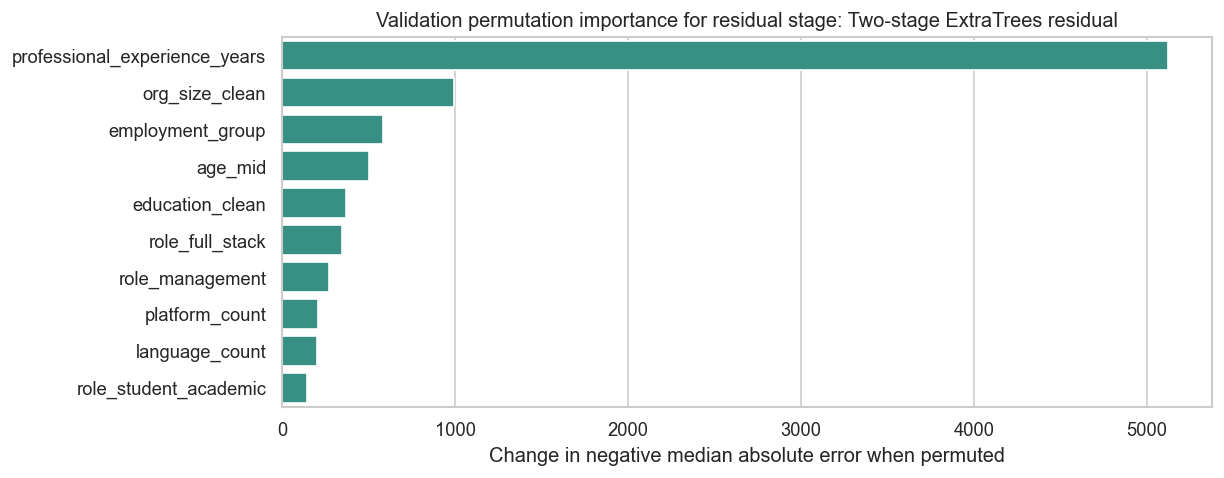

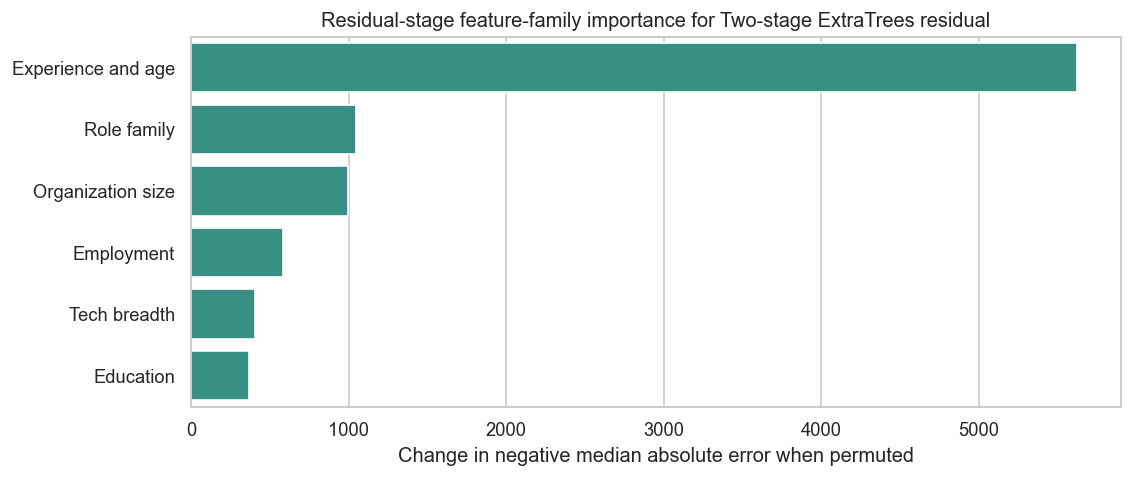

In [12]:
if best_two_stage_name == 'Two-stage Ridge residual':
    best_two_stage_valid_model = resid_ridge_valid_model
    best_two_stage_valid_base = resid_ridge_valid_base
elif best_two_stage_name == 'Two-stage ElasticNet residual':
    best_two_stage_valid_model = resid_elastic_valid_model
    best_two_stage_valid_base = resid_elastic_valid_base
else:
    best_two_stage_valid_model = resid_extra_valid_model
    best_two_stage_valid_base = resid_extra_valid_base

two_stage_family_map = {
    'employment_group': 'Employment',
    'education_clean': 'Education',
    'org_size_clean': 'Organization size',
    'age_mid': 'Experience and age',
    'professional_experience_years': 'Experience and age',
    'language_count': 'Tech breadth',
    'database_count': 'Tech breadth',
    'platform_count': 'Tech breadth'
}
for col in role_cols:
    two_stage_family_map[col] = 'Role family'

two_stage_wrapper = ResidualStageWrapper(best_two_stage_valid_base, best_two_stage_valid_model)

two_stage_perm_raw = permutation_importance(
    two_stage_wrapper,
    core_valid[RESIDUAL_FEATURES],
    core_valid[TARGET_COL],
    scoring=medae_real_loss,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

two_stage_perm_df = pd.DataFrame({
    'feature': RESIDUAL_FEATURES,
    'importance': two_stage_perm_raw.importances_mean,
    'family': [two_stage_family_map.get(col, 'Other') for col in RESIDUAL_FEATURES]
}).sort_values('importance', ascending=False)

two_stage_family_imp = two_stage_perm_df.groupby('family', as_index=False)['importance'].sum().sort_values('importance', ascending=False)

print(f"Top 15 residual-stage features for {best_two_stage_name}:")
display(two_stage_perm_df.head(15).round(2))
print("\nSummed residual-stage importance by feature family:")
display(two_stage_family_imp.round(2))

plt.figure(figsize=(10, 4))
sns.barplot(data=two_stage_perm_df.head(10), x='importance', y='feature', color='#2A9D8F')
plt.title(f"Validation permutation importance for residual stage: {best_two_stage_name}")
plt.xlabel("Change in negative median absolute error when permuted")
plt.ylabel("")
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=two_stage_family_imp, x='importance', y='family', color='#2A9D8F')
plt.title(f"Residual-stage feature-family importance for {best_two_stage_name}")
plt.xlabel("Change in negative median absolute error when permuted")
plt.ylabel("")
plt.show()


## Categorical Response Audit

This is a compact year-by-year lookup for the unique response levels in every categorical column of `clean_core`. Multi-select text fields are split on `;` first so the preview reflects actual response options rather than raw combined strings.

In [ ]:
# Summarize all categorical response levels by survey year
cat_features = [
    col
    for col in clean_core.columns
    if (
        clean_core[col].dtype == object
        or isinstance(clean_core[col].dtype, pd.CategoricalDtype)
    ) and col != 'survey_year_str'
]

def summarize_levels(series, max_levels=12):
    values = series.dropna().astype(str).str.split(';').explode().str.strip()
    levels = sorted({value for value in values.unique() if value not in {'', 'nan'}})
    preview = ' | '.join(levels[:max_levels])
    if len(levels) > max_levels:
        preview = f"{preview} | ... (+{len(levels) - max_levels} more)"
    return len(levels), preview

rows = []
for year, year_df in clean_core.groupby('survey_year'):
    for col in cat_features:
        n_levels, preview = summarize_levels(year_df[col])
        rows.append({
            'survey_year': year,
            'feature': col,
            'n_levels': n_levels,
            'levels_preview': preview
        })

cat_level_summary = pd.DataFrame(rows).sort_values(['survey_year', 'feature'])
cat_level_summary = cat_level_summary.set_index(['survey_year', 'feature'])
cat_level_counts = cat_level_summary['n_levels'].unstack('feature')

print("Unique categorical level counts by survey year:")
display(cat_level_counts)

print("\nPreview of categorical response levels by survey year:")
display(
    cat_level_summary.style.set_properties(
        subset=['levels_preview'],
        **{'white-space': 'pre-wrap'}
    )
)


## Next Steps

- Rerun the full notebook end to end and confirm whether the two-stage residual model still beats the best single-stage core model on the saved outputs
- Extend the two-stage setup to the 2021+ tech-rich window so remote work, learning channels, and newer tech-breadth fields can explain the within-country residual
- Add subgroup diagnostics on the 2025 test year by role family and employment type within the focal countries
- Potentially revise the rule used to trim valid compensation values to winsorize value instead

## Experimentation with LightGBM

### Base LightGBM Model

Basic setup and data splitting for LGB

In [ ]:
import lightgbm as lgb
import optuna
import shap


# Extract Top N Technologies
def extract_top_techs(df, col, n=15):
    # Flatten the semi-colon separated lists and get value counts
    all_techs = df[col].dropna().astype(str).str.split(';').explode().str.strip()
    top_techs = all_techs.value_counts().head(n).index.tolist()

    # Create boolean columns for each top tech
    for tech in top_techs:
        safe_name = f"{col}_{tech.replace(' ', '_').replace('.', 'dot')}"
        df[safe_name] = df[col].fillna('').str.contains(tech, regex=False).astype(int)
    return [f"{col}_{tech.replace(' ', '_').replace('.', 'dot')}" for tech in top_techs]

# Extract top languages, databases, and platforms
top_lang_cols = extract_top_techs(core_df, 'language', n=15)
top_db_cols = extract_top_techs(core_df, 'database', n=10)
top_plat_cols = extract_top_techs(core_df, 'platform', n=10)

# Update feature lists
TECH_BOOL_COLS = top_lang_cols + top_db_cols + top_plat_cols
LGB_FEATURES = CORE_CAT + CORE_NUM + TECH_BOOL_COLS

# LightGBM handles categorical features natively, but they need to be of 'category' dtype
for col in CORE_CAT:
    core_df[col] = core_df[col].astype('category')

# Re-split with the new boolean columns and category dtypes
core_train, core_valid, core_test = split_years(core_df, [2019, 2020, 2021, 2022, 2023], 2024, 2025)


Define Optuna fine tuning trial objectives and run survey to obtain best parameters (based on median absolute error)

In [ ]:
def objective(trial):
    params = {
        'objective': 'regression_l1', # MAE/Median proxy
        'metric': 'l1',
        'boosting_type': 'gbdt',
        'device_type': 'gpu', # Utilize T4 GPU if in Colab runtime, don't run unless you have a powerful GPU
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'verbose': -1
    }

    # LightGBM Pipeline (no need for OrdinalEncoder/OneHotEncoder)
    # We only need to median-impute the numeric columns
    num_imputer = SimpleImputer(strategy='median')
    X_train_num = num_imputer.fit_transform(core_train[CORE_NUM + TECH_BOOL_COLS])
    X_valid_num = num_imputer.transform(core_valid[CORE_NUM + TECH_BOOL_COLS])

    X_train_cat = core_train[CORE_CAT]
    X_valid_cat = core_valid[CORE_CAT]

    X_train_lgb = pd.concat([X_train_cat.reset_index(drop=True), pd.DataFrame(X_train_num, columns=CORE_NUM + TECH_BOOL_COLS)], axis=1)
    X_valid_lgb = pd.concat([X_valid_cat.reset_index(drop=True), pd.DataFrame(X_valid_num, columns=CORE_NUM + TECH_BOOL_COLS)], axis=1)

    y_train = core_train[TARGET_COL].values
    y_valid = core_valid[TARGET_COL].values

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_lgb, y_train,
        eval_set=[(X_valid_lgb, y_valid)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    preds = model.predict(X_valid_lgb)

    # Calculate Median Absolute Error in Real Dollars
    return median_absolute_error(np.exp(y_valid), np.exp(preds))

# Run Optuna Study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # Increase n_trials for better tuning

print("Best Trial Params:", study.best_trial.params)
print("Best Valid MedAE:", study.best_value)


[I 2026-04-01 20:36:19,795] A new study created in memory with name: no-name-701f5820-865c-416c-8b89-faedc88f22e5
[I 2026-04-01 20:37:01,240] Trial 0 finished with value: 14799.054475689558 and parameters: {'n_estimators': 877, 'learning_rate': 0.045856935163115745, 'num_leaves': 79, 'max_depth': 18, 'min_child_samples': 33, 'subsample': 0.7764167922541461, 'colsample_bytree': 0.657402560312361, 'reg_alpha': 1.3144105070940702e-06, 'reg_lambda': 0.008140567219296038}. Best is trial 0 with value: 14799.054475689558.
[I 2026-04-01 20:37:33,182] Trial 1 finished with value: 14852.789421706275 and parameters: {'n_estimators': 769, 'learning_rate': 0.03675260607463043, 'num_leaves': 75, 'max_depth': 10, 'min_child_samples': 43, 'subsample': 0.7678363157041405, 'colsample_bytree': 0.6577304563034815, 'reg_alpha': 6.303431355727195e-06, 'reg_lambda': 1.8476378888461125}. Best is trial 0 with value: 14799.054475689558.
[I 2026-04-01 20:37:55,109] Trial 2 finished with value: 14937.50432072505 

Best Trial Params: {'n_estimators': 659, 'learning_rate': 0.04280768609535672, 'num_leaves': 104, 'max_depth': 11, 'min_child_samples': 22, 'subsample': 0.6872084049537491, 'colsample_bytree': 0.7368883480938272, 'reg_alpha': 9.28733327190043, 'reg_lambda': 3.8666260444964735e-07}
Best Valid MedAE: 14650.989130303136


Use the parameters from the best performing trial to train a final model. Output evaluation metrics and SHAP values to determine feature importance

Test Metrics for Best LightGBM: {'medae_real': np.float64(17270.156370291264), 'mae_real': 31718.77544796986, 'rmse_real': np.float64(62773.670477203974), 'rmse_log': np.float64(0.6907876806029357), 'r2_log': 0.5659196664168252}


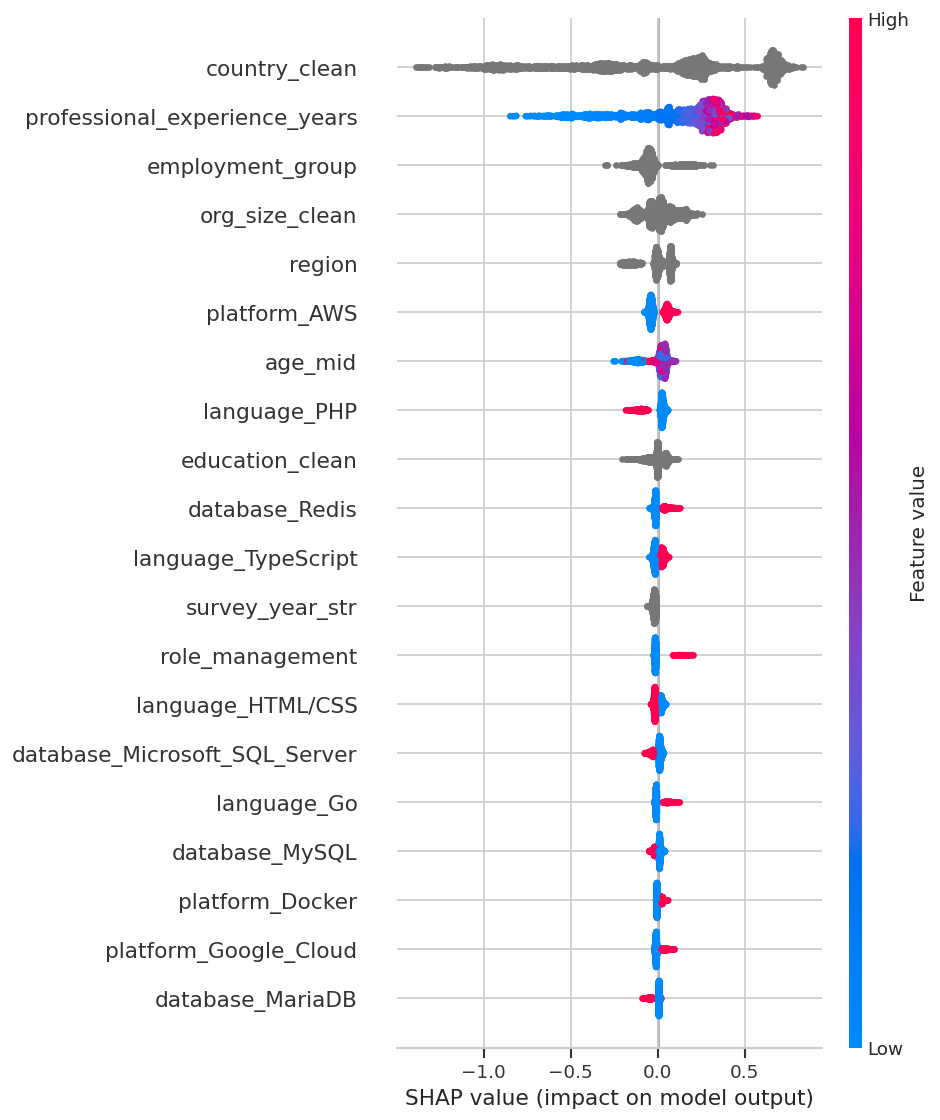

In [ ]:
# Train final best model
best_params = study.best_trial.params
best_params['objective'] = 'regression_l1'
best_params['device_type'] = 'gpu'
best_params['verbose'] = -1
best_params['random_state'] = RANDOM_STATE

# Preprocess full train+valid
num_imputer = SimpleImputer(strategy='median')
full_train = pd.concat([core_train, core_valid], axis=0)
X_full_num = num_imputer.fit_transform(full_train[CORE_NUM + TECH_BOOL_COLS])
X_full_cat = full_train[CORE_CAT].reset_index(drop=True)
X_full = pd.concat([X_full_cat, pd.DataFrame(X_full_num, columns=CORE_NUM + TECH_BOOL_COLS)], axis=1)
y_full = full_train[TARGET_COL].values

final_lgb = lgb.LGBMRegressor(**best_params)
final_lgb.fit(X_full, y_full)

# Preprocess Test
X_test_num = num_imputer.transform(core_test[CORE_NUM + TECH_BOOL_COLS])
X_test_cat = core_test[CORE_CAT].reset_index(drop=True)
X_test = pd.concat([X_test_cat, pd.DataFrame(X_test_num, columns=CORE_NUM + TECH_BOOL_COLS)], axis=1)
y_test = core_test[TARGET_COL].values

test_preds = final_lgb.predict(X_test)
test_metrics = score_predictions(y_test, test_preds)
print("Test Metrics for Best LightGBM:", test_metrics)

# SHAP Values
# We use a sample of the test set for SHAP to save computation time
X_shap_sample = X_test.sample(2000, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(final_lgb)
shap_values = explainer(X_shap_sample)

# Summary Plot
shap.summary_plot(shap_values, X_shap_sample, max_display=20)


### Winsorized LightGBM Model

Train a new model with numeric columns being winsorized to attempt to control outliers and normalize the data more then compare metrics to previous model.

In [ ]:
# Apply Group-Wise Winsorization
def winsorize_group(x):
    # Only winsorize if the group has enough samples to make percentiles meaningful
    if len(x) < 20:
        return x
    lower = x.quantile(0.01)
    upper = x.quantile(0.99)
    return x.clip(lower=lower, upper=upper)

# Apply to real 2025 compensation grouped by year and country
core_df['comp_real_2025_winsor'] = core_df.groupby(['survey_year', 'country_clean'])['comp_real_2025'].transform(winsorize_group)
core_df['log_comp_real_2025_winsor'] = np.log(core_df['comp_real_2025_winsor'])

# Update target column for this run
WINSOR_TARGET_COL = 'log_comp_real_2025_winsor'

# Re-split data with the new target
core_train, core_valid, core_test = split_years(core_df, [2019, 2020, 2021, 2022, 2023], 2024, 2025)

# Preprocess Data
num_imputer = SimpleImputer(strategy='median')
full_train = pd.concat([core_train, core_valid], axis=0)

X_full_num = num_imputer.fit_transform(full_train[CORE_NUM + TECH_BOOL_COLS])
X_full_cat = full_train[CORE_CAT].reset_index(drop=True)
X_full = pd.concat([X_full_cat, pd.DataFrame(X_full_num, columns=CORE_NUM + TECH_BOOL_COLS)], axis=1)
y_full_winsor = full_train[WINSOR_TARGET_COL].values

X_test_num = num_imputer.transform(core_test[CORE_NUM + TECH_BOOL_COLS])
X_test_cat = core_test[CORE_CAT].reset_index(drop=True)
X_test = pd.concat([X_test_cat, pd.DataFrame(X_test_num, columns=CORE_NUM + TECH_BOOL_COLS)], axis=1)
y_test_winsor = core_test[WINSOR_TARGET_COL].values

# Train LightGBM on Winsorized Target
winsor_lgb = lgb.LGBMRegressor(**best_params)
winsor_lgb.fit(X_full, y_full_winsor)

# Evaluate
winsor_preds = winsor_lgb.predict(X_test)
winsor_metrics = score_predictions(y_test_winsor, winsor_preds)

# Compare with previous best
winsor_comparison = pd.DataFrame([
    {
        'model': 'LightGBM (Original Target)',
        'test_medae_real': test_metrics['medae_real'],
        'test_mae_real': test_metrics['mae_real'],
        'test_rmse_real': test_metrics['rmse_real'],
        'test_r2_log': test_metrics['r2_log']
    },
    {
        'model': 'LightGBM (Winsorized Target)',
        'test_medae_real': winsor_metrics['medae_real'],
        'test_mae_real': winsor_metrics['mae_real'],
        'test_rmse_real': winsor_metrics['rmse_real'],
        'test_r2_log': winsor_metrics['r2_log']
    }
])

print("Impact of Localized Winsorization on LightGBM Performance:")
display(winsor_comparison.round(2))

Impact of Localized Winsorization on LightGBM Performance:


,model,test_medae_real,test_mae_real,test_rmse_real,test_r2_log
0,LightGBM (Original Target),17270.16,31718.78,62773.67,0.57
1,LightGBM (Winsorized Target),17383.34,30299.03,52700.18,0.58


### Side Window LightGBM Model

Compare model performance on the two narrow Tech and AI side windows (2019+ is base window, 2021+ is tech window, and 2023+ is AI window)

In [ ]:
import shap

# Helper to map core features onto side windows
def apply_core_tech_booleans(df):
    for col_name in TECH_BOOL_COLS:
        if col_name.startswith('language_'):
            tech = col_name.replace('language_', '').replace('_', ' ').replace('dot', '.')
            df[col_name] = df['language'].fillna('').str.contains(tech, regex=False).astype(int)
        elif col_name.startswith('database_'):
            tech = col_name.replace('database_', '').replace('_', ' ').replace('dot', '.')
            df[col_name] = df['database'].fillna('').str.contains(tech, regex=False).astype(int)
        elif col_name.startswith('platform_'):
            tech = col_name.replace('platform_', '').replace('_', ' ').replace('dot', '.')
            df[col_name] = df['platform'].fillna('').str.contains(tech, regex=False).astype(int)
    return df



# ============== 2021+ Tech Window ==============
# Winsorize
tech_df['comp_real_2025_winsor'] = tech_df.groupby(['survey_year', 'country_clean'])['comp_real_2025'].transform(winsorize_group)
tech_df[WINSOR_TARGET_COL] = np.log(tech_df['comp_real_2025_winsor'])

# Extract Tech Booleans matching core model
tech_df = apply_core_tech_booleans(tech_df)

# Convert Categoricals
for col in TECH_CAT:
    tech_df[col] = tech_df[col].astype('category')

# Split
tech_train, tech_valid, tech_test = split_years(tech_df, [2021, 2022, 2023], 2024, 2025)

# Preprocess
tech_features_num = TECH_NUM + TECH_BOOL_COLS
tech_num_imputer = SimpleImputer(strategy='median')
tech_full_train = pd.concat([tech_train, tech_valid], axis=0)

X_tech_full_num = tech_num_imputer.fit_transform(tech_full_train[tech_features_num])
X_tech_full = pd.concat([tech_full_train[TECH_CAT].reset_index(drop=True), pd.DataFrame(X_tech_full_num, columns=tech_features_num)], axis=1)
y_tech_full = tech_full_train[WINSOR_TARGET_COL].values

X_tech_test_num = tech_num_imputer.transform(tech_test[tech_features_num])
X_tech_test = pd.concat([tech_test[TECH_CAT].reset_index(drop=True), pd.DataFrame(X_tech_test_num, columns=tech_features_num)], axis=1)
y_tech_test = tech_test[WINSOR_TARGET_COL].values

# Train
tech_lgb = lgb.LGBMRegressor(**best_params)
tech_lgb.fit(X_tech_full, y_tech_full)
tech_preds = tech_lgb.predict(X_tech_test)
tech_metrics = score_predictions(y_tech_test, tech_preds)

print("Test Metrics for 2021+ Tech LightGBM (Winsorized):", tech_metrics)



# ============== 2023+ AI Window ==============
# Winsorize
ai_df['comp_real_2025_winsor'] = ai_df.groupby(['survey_year', 'country_clean'])['comp_real_2025'].transform(winsorize_group)
ai_df[WINSOR_TARGET_COL] = np.log(ai_df['comp_real_2025_winsor'])

# Extract Tech Booleans matching core model
ai_df = apply_core_tech_booleans(ai_df)

# Convert Categoricals
for col in AI_CAT:
    ai_df[col] = ai_df[col].astype('category')

# Split
ai_train, ai_valid, ai_test = split_years(ai_df, [2023], 2024, 2025)

# Preprocess
ai_features_num = AI_NUM + TECH_BOOL_COLS
ai_num_imputer = SimpleImputer(strategy='median')
ai_full_train = pd.concat([ai_train, ai_valid], axis=0)

X_ai_full_num = ai_num_imputer.fit_transform(ai_full_train[ai_features_num])
X_ai_full = pd.concat([ai_full_train[AI_CAT].reset_index(drop=True), pd.DataFrame(X_ai_full_num, columns=ai_features_num)], axis=1)
y_ai_full = ai_full_train[WINSOR_TARGET_COL].values

X_ai_test_num = ai_num_imputer.transform(ai_test[ai_features_num])
X_ai_test = pd.concat([ai_test[AI_CAT].reset_index(drop=True), pd.DataFrame(X_ai_test_num, columns=ai_features_num)], axis=1)
y_ai_test = ai_test[WINSOR_TARGET_COL].values

# Train
ai_lgb = lgb.LGBMRegressor(**best_params)
ai_lgb.fit(X_ai_full, y_ai_full)
ai_preds = ai_lgb.predict(X_ai_test)
ai_metrics = score_predictions(y_ai_test, ai_preds)

print("Test Metrics for 2023+ AI LightGBM (Winsorized):", ai_metrics)

Test Metrics for 2021+ Tech LightGBM (Winsorized): {'medae_real': np.float64(17286.8640946412), 'mae_real': 30247.493361632376, 'rmse_real': np.float64(52865.43207548988), 'rmse_log': np.float64(0.6654036617156401), 'r2_log': 0.5810377507391831}
Test Metrics for 2023+ AI LightGBM (Winsorized): {'medae_real': np.float64(17402.355276930983), 'mae_real': 30120.034216755506, 'rmse_real': np.float64(52800.42582552656), 'rmse_log': np.float64(0.6587457276465143), 'r2_log': 0.5893799583594465}


SHAP snalysis for side windows


Generating SHAP Summary for 2021+ Tech Window...


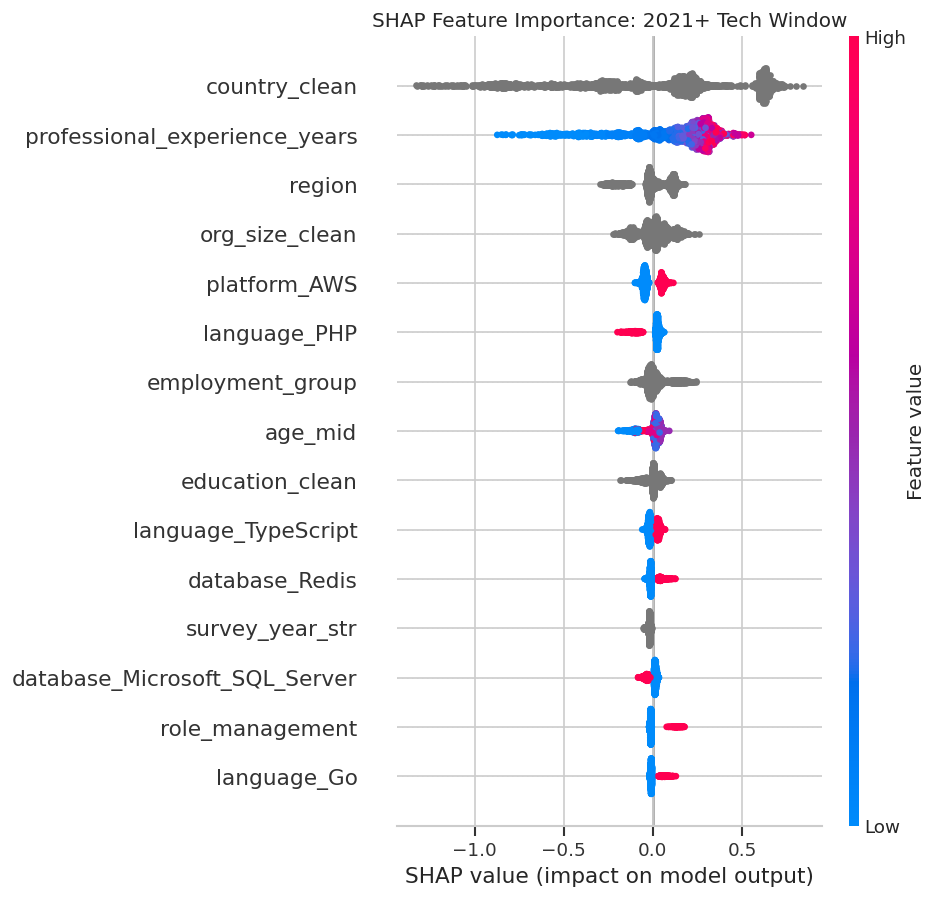


Generating SHAP Summary for 2023+ AI Window...


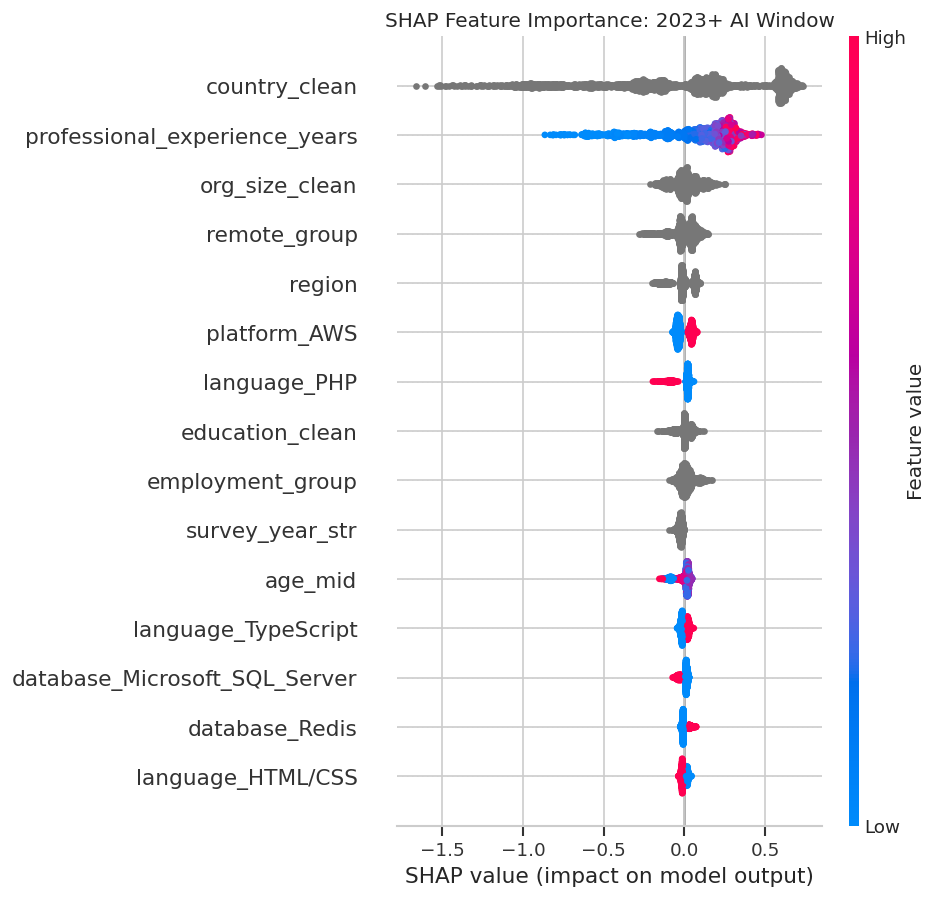

In [ ]:
plt.figure(figsize=(15, 6))

print("Generating SHAP Summary for 2021+ Tech Window...")
X_tech_shap = X_tech_test.sample(min(2000, len(X_tech_test)), random_state=RANDOM_STATE)
tech_explainer = shap.TreeExplainer(tech_lgb)
tech_shap_values = tech_explainer(X_tech_shap)
shap.summary_plot(tech_shap_values, X_tech_shap, max_display=15, show=False)
plt.title("SHAP Feature Importance: 2021+ Tech Window")
plt.show()

print("\nGenerating SHAP Summary for 2023+ AI Window...")
X_ai_shap = X_ai_test.sample(min(2000, len(X_ai_test)), random_state=RANDOM_STATE)
ai_explainer = shap.TreeExplainer(ai_lgb)
ai_shap_values = ai_explainer(X_ai_shap)
shap.summary_plot(ai_shap_values, X_ai_shap, max_display=15, show=False)
plt.title("SHAP Feature Importance: 2023+ AI Window")
plt.show()

### GDP PPP Corrected LightGBM Model

Try using World Bank's yearly Gross Domestic Product based on Purchasing Parity Power (GDP PPP) to align compensation more with each countries purchasing power.

This attempts to correct an issue with the assumption we make in just trying to model raw compensation (in USD). There are many countries where the USD goes much farther/buys much more than it does in the United States. Because of this, a lower salary compared to someone in the United States may actually have the same purchasing power and, therefore, we'd want their predictors to be similar. Using GDP PPP should hopefully normalize this effect.

In [ ]:
import requests

print("Fetching World Bank Data (GDP per capita, PPP)...")
# Indicator: NY.GDP.PCAP.PP.CD (GDP per capita, PPP (current international $))
url = "http://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.PP.CD?format=json&per_page=300&date=2022"
response = requests.get(url)
data = response.json()

wb_records = []
for item in data[1]:
    if item['value'] is not None:
        wb_records.append({
            'country_raw': item['country']['value'],
            'gdp_ppp': item['value']
        })

wb_df = pd.DataFrame(wb_records)

# Map World Bank names to cleaned country names
name_mapping = {
    'Russian Federation': 'Russia',
    'Turkiye': 'Türkiye',
    'Turkey': 'Türkiye',
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Venezuela, RB': 'Venezuela',
    'Czechia': 'Czech Republic',
    'Slovak Republic': 'Slovakia',
    'Hong Kong SAR, China': 'Hong Kong (S.A.R.)',
    'Viet Nam': 'Vietnam'
}
wb_df['country_clean'] = wb_df['country_raw'].replace(name_mapping)
wb_df = wb_df[['country_clean', 'gdp_ppp']].drop_duplicates('country_clean')

# Merge with core_df
core_macro = core_df.merge(wb_df, on='country_clean', how='left')

# Impute missing macroeconomic data using regional median, then global median
core_macro['gdp_ppp'] = core_macro['gdp_ppp'].fillna(core_macro.groupby('region')['gdp_ppp'].transform('median'))
core_macro['gdp_ppp'] = core_macro['gdp_ppp'].fillna(core_macro['gdp_ppp'].median())

# Log-transform GDP PPP since macroeconomic data is highly skewed
core_macro['log_gdp_ppp'] = np.log(core_macro['gdp_ppp'])

print(f"Successfully merged Macroeconomic data. Missing values remaining: {core_macro['log_gdp_ppp'].isna().sum()}")
display(core_macro[['country_clean', 'region', 'gdp_ppp', 'log_gdp_ppp']].sample(5, random_state=RANDOM_STATE))

Fetching World Bank Data (GDP per capita, PPP)...
Successfully merged Macroeconomic data! Missing values remaining: 0


,country_clean,region,gdp_ppp,log_gdp_ppp
144862,Portugal,Europe,45250.014876,10.719958
209598,Australia,Oceania,66103.179707,11.098972
200160,Uganda,Africa,2919.177754,7.979057
12772,Ukraine,Europe,14770.071289,9.600358
20175,United States,Americas,77860.911291,11.262679


Train model with transformed GDP PPP values then evaluate it and display SHAP values

Training LightGBM with Macroeconomic Features...

Test Metrics for LightGBM (With Macroeconomic Data):
  medae_real: 17278.9995
  mae_real: 30233.5184
  rmse_real: 52584.5735
  rmse_log: 0.6597
  r2_log: 0.5882

Generating SHAP Summary...


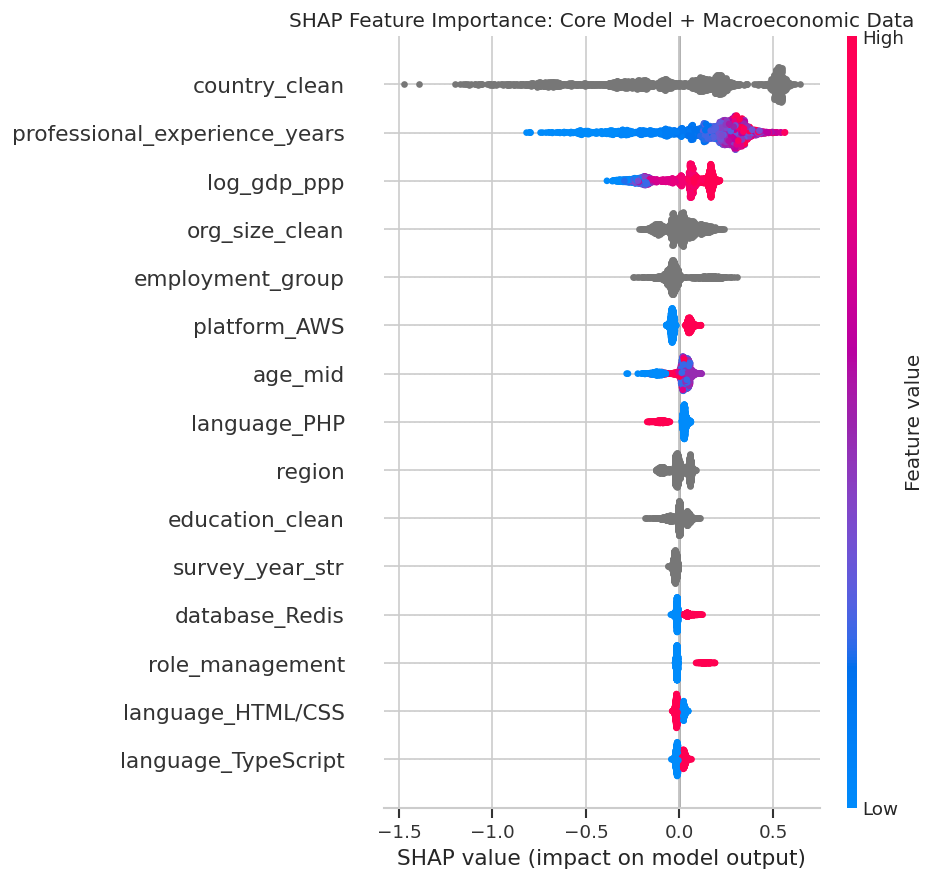

In [ ]:
# Update feature lists
MACRO_NUM = CORE_NUM + TECH_BOOL_COLS + ['log_gdp_ppp']
MACRO_CAT = CORE_CAT.copy()

# Ensure categorical columns are of 'category' dtype
for col in MACRO_CAT:
    core_macro[col] = core_macro[col].astype('category')

# Re-split data
macro_train, macro_valid, macro_test = split_years(core_macro, [2019, 2020, 2021, 2022, 2023], 2024, 2025)
macro_full_train = pd.concat([macro_train, macro_valid], axis=0)

# Preprocess
num_imputer = SimpleImputer(strategy='median')
X_macro_full_num = num_imputer.fit_transform(macro_full_train[MACRO_NUM])
X_macro_full = pd.concat([macro_full_train[MACRO_CAT].reset_index(drop=True), pd.DataFrame(X_macro_full_num, columns=MACRO_NUM)], axis=1)
y_macro_full = macro_full_train[WINSOR_TARGET_COL].values

X_macro_test_num = num_imputer.transform(macro_test[MACRO_NUM])
X_macro_test = pd.concat([macro_test[MACRO_CAT].reset_index(drop=True), pd.DataFrame(X_macro_test_num, columns=MACRO_NUM)], axis=1)
y_macro_test = macro_test[WINSOR_TARGET_COL].values

# Train LightGBM
print("Training LightGBM with Macroeconomic Features...")
macro_lgb = lgb.LGBMRegressor(**best_params)
macro_lgb.fit(X_macro_full, y_macro_full)

# Evaluate
macro_preds = macro_lgb.predict(X_macro_test)
macro_metrics = score_predictions(y_macro_test, macro_preds)

print("\nTest Metrics for LightGBM (With Macroeconomic Data):")
for k, v in macro_metrics.items():
    print(f"  {k}: {v:.4f}")

# SHAP Analysis
print("\nGenerating SHAP Summary...")
X_macro_shap = X_macro_test.sample(min(2000, len(X_macro_test)), random_state=RANDOM_STATE)
macro_explainer = shap.TreeExplainer(macro_lgb)
macro_shap_values = macro_explainer(X_macro_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(macro_shap_values, X_macro_shap, max_display=15, show=False)
plt.title("SHAP Feature Importance: Core Model + Macroeconomic Data")
plt.tight_layout()
plt.show()

### Locked Country/Region LightGBM Model

The two largest predictors are almost always country_clean and region by a large margin, since geography has many changes in how predictors work. Holding these constant and looking at a single country or region at a time should surface truly important predictive features.


Analyzing: United States
Test Metrics for United States:
  medae_real: 34124.1052
  mae_real: 51709.3646
  rmse_real: 80388.7167
  rmse_log: 0.4498
  r2_log: 0.3544


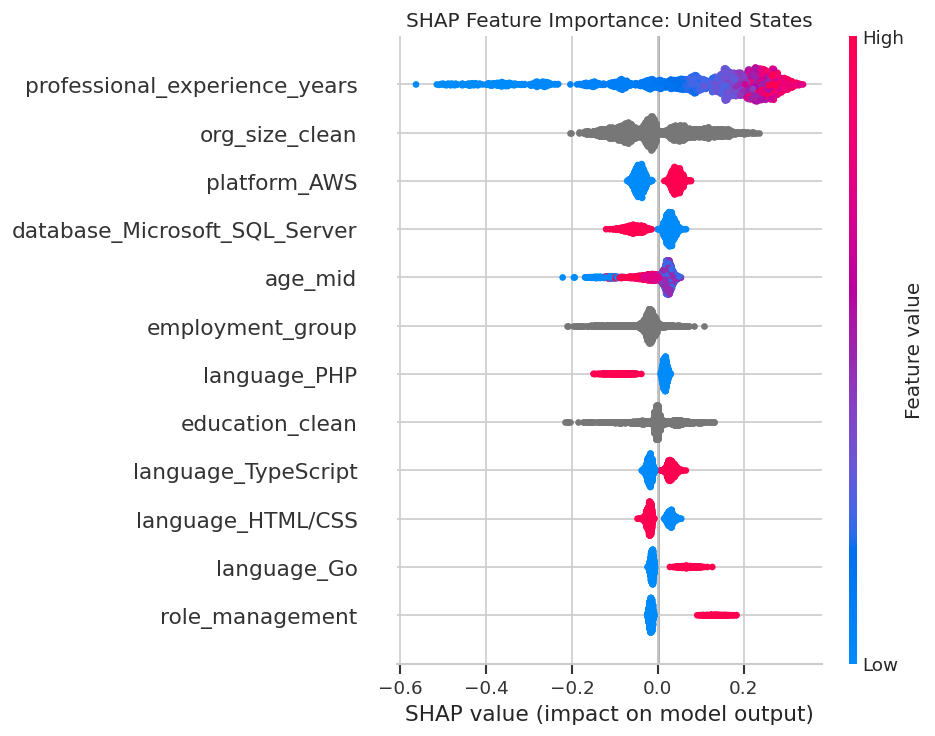


Analyzing: India
Test Metrics for India:
  medae_real: 8833.5928
  mae_real: 16248.9870
  rmse_real: 31242.4326
  rmse_log: 0.8486
  r2_log: 0.3840


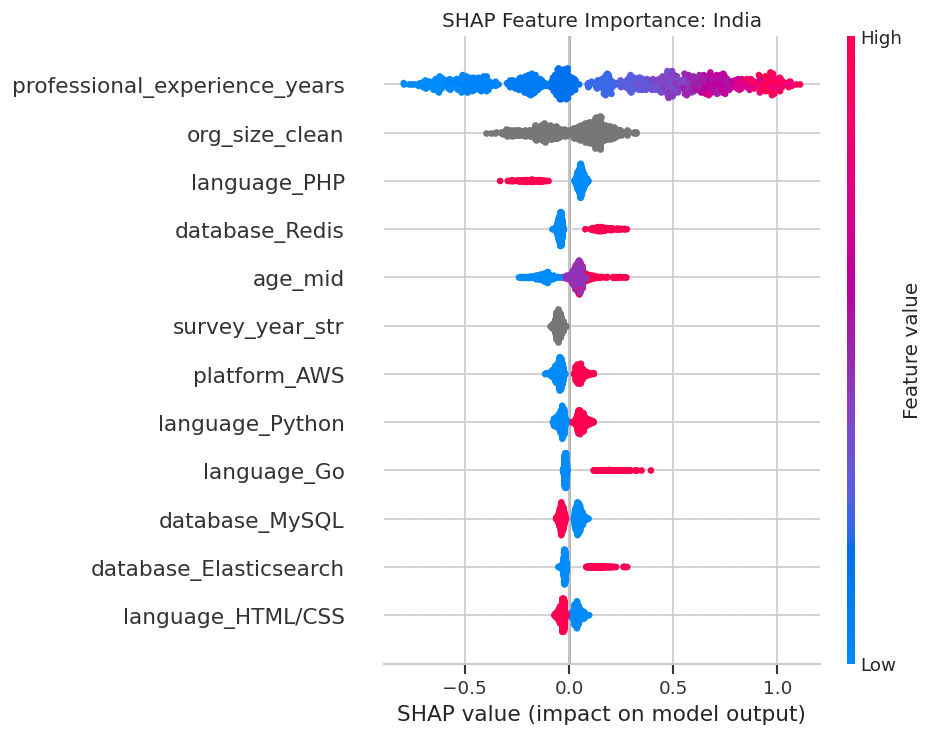


Analyzing: Europe
Test Metrics for Europe:
  medae_real: 20333.4899
  mae_real: 29675.1260
  rmse_real: 44429.3785
  rmse_log: 0.7118
  r2_log: 0.2280


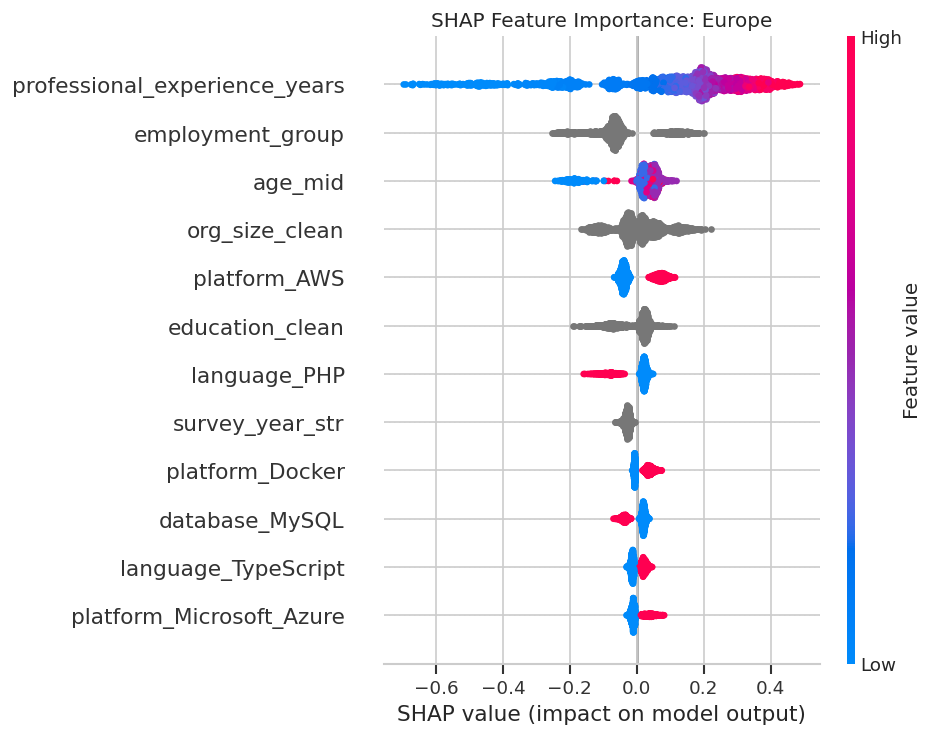

In [ ]:
def analyze_geography(geo_type, geo_name):
    print(f"\n{'='*50}")
    print(f"Analyzing: {geo_name}")
    print(f"{'='*50}")

    # Filter data based on whether it's a country or region
    if geo_type == 'country':
        geo_df = core_df[core_df['country_clean'] == geo_name].copy()
    else:
        geo_df = core_df[core_df['region'] == geo_name].copy()

    # Remove the geographic categorical features since they are constant (or redundant) here
    geo_cat = [col for col in CORE_CAT if col not in ['country_clean', 'region']]
    geo_features_num = CORE_NUM + TECH_BOOL_COLS

    # We need to make sure the categoricals are still treated as 'category' dtype
    for col in geo_cat:
        geo_df[col] = geo_df[col].astype('category')

    # Split data
    geo_train, geo_valid, geo_test = split_years(geo_df, [2019, 2020, 2021, 2022, 2023], 2024, 2025)

    if len(geo_train) == 0 or len(geo_test) == 0:
        print(f"Not enough data to analyze {geo_name}.")
        return

    # Preprocess
    geo_num_imputer = SimpleImputer(strategy='median')
    geo_full_train = pd.concat([geo_train, geo_valid], axis=0)

    X_full_num = geo_num_imputer.fit_transform(geo_full_train[geo_features_num])
    X_full = pd.concat([geo_full_train[geo_cat].reset_index(drop=True), pd.DataFrame(X_full_num, columns=geo_features_num)], axis=1)
    y_full = geo_full_train[WINSOR_TARGET_COL].values

    X_test_num = geo_num_imputer.transform(geo_test[geo_features_num])
    X_test = pd.concat([geo_test[geo_cat].reset_index(drop=True), pd.DataFrame(X_test_num, columns=geo_features_num)], axis=1)
    y_test = geo_test[WINSOR_TARGET_COL].values

    # Train
    model = lgb.LGBMRegressor(**best_params)
    model.fit(X_full, y_full)

    # Evaluate
    preds = model.predict(X_test)
    metrics = score_predictions(y_test, preds)
    print(f"Test Metrics for {geo_name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

    # SHAP Analysis
    X_shap = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_shap)

    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, X_shap, max_display=12, show=False)
    plt.title(f"SHAP Feature Importance: {geo_name}")
    plt.tight_layout()
    plt.show()

# Run the analysis for the requested areas
analyze_geography('country', 'United States')
analyze_geography('country', 'India')
analyze_geography('region', 'Europe')